In [1]:
import pandas as pd
import numpy as np
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.stats import zscore
data_log2_Coimbra = pd.read_pickle('data_log2_Coimbra_threshold.pkl')
data_log2_LC = pd.read_pickle('data_log2_Lisbon_Coimbra_threshold.pkl')
data_log2_Lisbon = pd.read_pickle('data_log2_Lisbon_threshold.pkl')
import pickle
with open('prot_Coimbra.pkl', 'rb') as f:
    prot_Coimbra = pickle.load(f)
print(prot_Coimbra)
with open('prot_Lisbon.pkl', 'rb') as f:
    prot_Lisbon = pickle.load(f)
with open('prot_LC.pkl', 'rb') as f:
    prot_LC = pickle.load(f)
with open('list_groups_Coimbra.pkl', 'rb') as f:
    list_groups_Coimbra = pickle.load(f)

print(len(list_groups_Coimbra))


with open('list_groups_LC.pkl', 'rb') as f:
    list_groups_LC = pickle.load(f)

print(len(list_groups_LC))

with open('list_groups.pkl', 'rb') as f:
    list_groups_Lisbon = pickle.load(f)

print(len(list_groups_Lisbon))

Index(['Q14982', 'P02790', 'P07477', 'Q12805', 'P07339', 'Q13449', 'Q92876',
       'Q14118', 'P05090', 'P01023',
       ...
       'P06312', 'Q5SYB0', 'P01042', 'Q969P0', 'P05546', 'Q15582', 'Q13822',
       'Q14393', 'P35527', 'O00584'],
      dtype='object', length=115)
55
125
64


In [2]:
import numpy as np

# =========================
# --- COIMBRA ---
# =========================

groups_Coimbra = np.array(list_groups_Coimbra).astype(str)
groups_Coimbra = np.char.strip(groups_Coimbra)

mask_ad_Coimbra = groups_Coimbra == "MCI-AD"
mask_ctrl_Coimbra = groups_Coimbra == "MCI-CT"  

# NON sovrascrivo data_log2_Coimbra
data_AD_Coimbra = data_log2_Coimbra.loc[mask_ad_Coimbra]
data_CTRL_Coimbra = data_log2_Coimbra.loc[mask_ctrl_Coimbra]

proteins_Coimbra = prot_Coimbra.tolist()

proteins_present_Coimbra = data_log2_Coimbra.columns.intersection(proteins_Coimbra)

# mantengo naming coerente con pipeline
filtered_data_Coimbra = data_AD_Coimbra[proteins_present_Coimbra]
filtered_ctrl_Coimbra = data_CTRL_Coimbra[proteins_present_Coimbra]


# =========================
# --- LISBON ---
# =========================

groups_Lisbon = np.array(list_groups_Lisbon).astype(str)
groups_Lisbon = np.char.strip(groups_Lisbon)

mask_ad_Lisbon = groups_Lisbon == "MCI-AD"
mask_ctrl_Lisbon = groups_Lisbon == "MCI-CT"

data_AD_Lisbon = data_log2_Lisbon.loc[mask_ad_Lisbon]
data_CTRL_Lisbon = data_log2_Lisbon.loc[mask_ctrl_Lisbon]

proteins_Lisbon = prot_Lisbon.tolist()

proteins_present_Lisbon = data_log2_Lisbon.columns.intersection(proteins_Lisbon)

filtered_data_Lisbon = data_AD_Lisbon[proteins_present_Lisbon]
filtered_ctrl_Lisbon = data_CTRL_Lisbon[proteins_present_Lisbon]


# =========================
# --- LC (Merged) ---
# =========================

groups_LC = np.array(list_groups_LC).astype(str)
groups_LC = np.char.strip(groups_LC)

mask_ad_LC = groups_LC == "MCI-AD"
mask_ctrl_LC = groups_LC == "MCI-CT"

data_AD_LC = data_log2_LC.loc[mask_ad_LC]
data_CTRL_LC = data_log2_LC.loc[mask_ctrl_LC]

proteins_LC = prot_LC.tolist()

proteins_present_LC = data_log2_LC.columns.intersection(proteins_LC)

filtered_data_LC = data_AD_LC[proteins_present_LC]
filtered_ctrl_LC = data_CTRL_LC[proteins_present_LC]

In [3]:
proteins_present_Coimbra = proteins_present_Coimbra.tolist()
proteins_present_Lisbon = proteins_present_Lisbon.tolist()
proteins_present_LC = proteins_present_LC.tolist()

In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

# --- COIMBRA ---
X_scaled_Coimbra = scaler.fit_transform(filtered_data_Coimbra)
Coimbra_df = pd.DataFrame(
    X_scaled_Coimbra,
    index=filtered_data_Coimbra.index,
    columns=filtered_data_Coimbra.columns
)
# solo per NMF
Coimbra_nmf_df = pd.DataFrame(
    X_scaled_Coimbra - X_scaled_Coimbra.min(),
    index=filtered_data_Coimbra.index,
    columns=filtered_data_Coimbra.columns
)

# --- LISBON ---
X_scaled_Lisbon = scaler.fit_transform(filtered_data_Lisbon)
Lisbon_df = pd.DataFrame(
    X_scaled_Lisbon,
    index=filtered_data_Lisbon.index,
    columns=filtered_data_Lisbon.columns
)
# solo per NMF
Lisbon_nmf_df = pd.DataFrame(
    X_scaled_Lisbon - X_scaled_Lisbon.min(),
    index=filtered_data_Lisbon.index,
    columns=filtered_data_Lisbon.columns
)

# --- LC ---
X_scaled_LC = scaler.fit_transform(filtered_data_LC)
LC_df = pd.DataFrame(
    X_scaled_LC,
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)
# solo per NMF
LC_nmf_df = pd.DataFrame(
    X_scaled_LC - X_scaled_LC.min(),
    index=filtered_data_LC.index,
    columns=filtered_data_LC.columns
)

Grafico salvato come: dist_comparison_noshift_coimbra.png


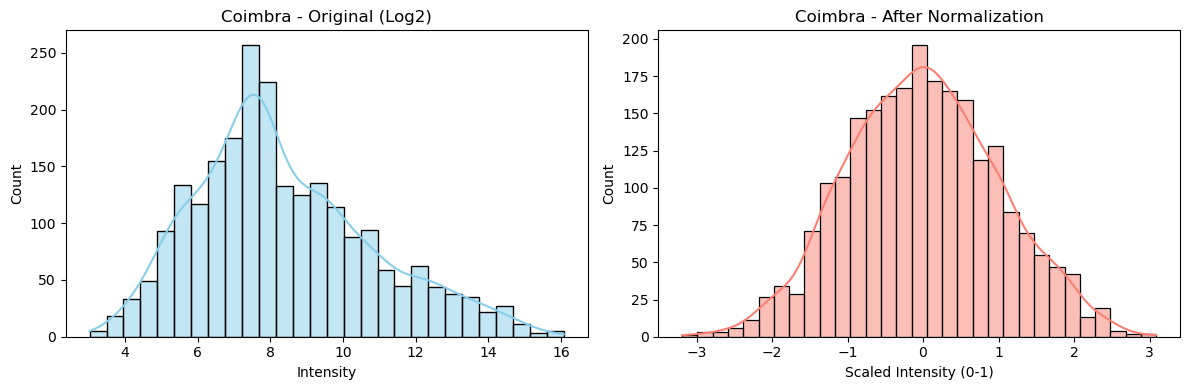

Grafico salvato come: dist_comparison_noshift_lisbon.png


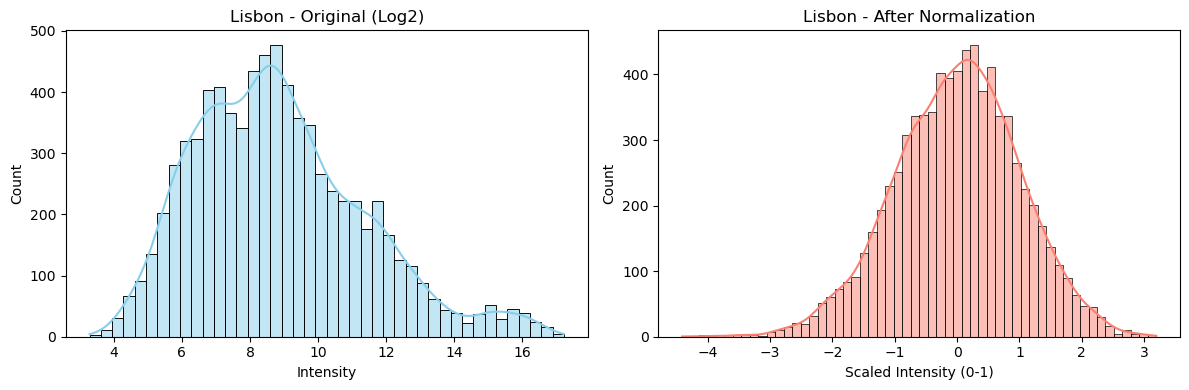

Grafico salvato come: dist_comparison_noshift_merged_lc.png


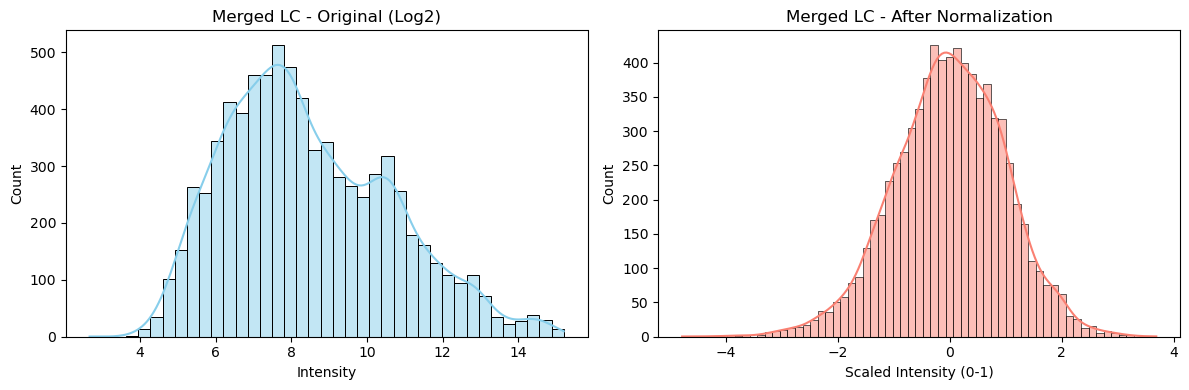

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution_comparison(original, scaled, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Distribuzione Log2 originale
    sns.histplot(original.values.flatten(), kde=True, ax=ax[0], color='skyblue')
    ax[0].set_title(f'{title} - Original (Log2)')
    ax[0].set_xlabel('Intensity')
    
    # Distribuzione dopo MinMaxScaler
    sns.histplot(scaled.flatten(), kde=True, ax=ax[1], color='salmon')
    ax[1].set_title(f'{title} - After Normalization')
    ax[1].set_xlabel('Scaled Intensity (0-1)')
    
    plt.tight_layout()
    
    # Rendiamo il nome del file dinamico basandoci sul titolo
    # Sostituiamo eventuali spazi o caratteri speciali per sicurezza
    filename = f"dist_comparison_noshift_{title.replace(' ', '_').lower()}.png"
    print(f"Grafico salvato come: {filename}")
    plt.savefig(filename)
    plt.show()

# Esecuzione (i file verranno salvati separatamente)
plot_distribution_comparison(filtered_data_Coimbra, X_scaled_Coimbra, "Coimbra")
plot_distribution_comparison(filtered_data_Lisbon, X_scaled_Lisbon  , "Lisbon")
plot_distribution_comparison(filtered_data_LC, X_scaled_LC , "Merged LC")

In [89]:
patients_coimbra_k3 = ['103698', '108726', '106022', '100855', '106746', '104804', '105438', '102357', '107362']
patients_lisbon_k3 = ['LIS090', 'LIS001', 'LIS029', 'LIS005', 'LIS012', 'LIS002', 'LIS013', 'LIS043', 'LIS040', 'LIS047', 'LIS051', 'LIS049', 'LIS057', 'LIS068', 'LIS076', 'LIS004', 'LIS027', 'LIS052', 'LIS061', 'LIS069', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102']
patients_lc_k3 = ['LIS090', 'LIS008', 'LIS011', 'LIS001', 'LIS031', 'LIS029', 'LIS005', 'LIS012', 'LIS018', 'LIS035', 'LIS033', 'LIS024', 'LIS002', 'LIS013', 'LIS043', 'LIS040', 'LIS047', 'LIS051', 'LIS049', 'LIS057', 'LIS064', 'LIS068', 'LIS076', 'LIS004', 'LIS027', 'LIS034', 'LIS052', 'LIS061', 'LIS069', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS103', 'LIS117', '108726', '106022', '100112', '104726', '109089', '102357', '109522']



# Coimbra
patients_coimbra = ['103698', '107702', '104804', '100111', '102357']

# Lisbon
patients_lisbon = ['LIS090', 'LIS029', 'LIS005', 'LIS002', 'LIS043', 'LIS051', 'LIS049', 'LIS064', 'LIS076', 'LIS052', 'LIS073', 'LIS081', 'LIS084', 'LIS087', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117']

# LC
patients_lc = ['LIS090', 'LIS011', 'LIS001', 'LIS029', 'LIS005', 'LIS012', 'LIS018', 'LIS002', 'LIS043', 'LIS047', 'LIS051', 'LIS049', 'LIS076', 'LIS004', 'LIS034', 'LIS058', 'LIS073', 'LIS081', 'LIS084', 'LIS085', 'LIS087', 'LIS088', 'LIS094', 'LIS096', 'LIS097', 'LIS102', 'LIS117', '106022', '100596', '101960', '104726', '105438', '105080', '109901', '109089', '103176', '102357', '109522']

In [7]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
def count_stable_patients(all_labels, df, patients_grey, name, threshold=0.6):

    print(f"\n{'='*60}")
    print(f"{name} — Stable patients (threshold = {int(threshold*100)}%)")
    print(f"{'='*60}")

    patients = df.index.tolist()
    grey_set = set(p for p in patients_grey if p in patients)
    non_grey = [p for p in patients if p not in grey_set]

    stable_flags = {}

    for p in patients:
        idx = df.index.get_loc(p)
        assigned = [labels[idx] for labels in all_labels]
        counts = pd.Series(assigned).value_counts(normalize=True)
        stable_flags[p] = counts.max() >= threshold

    grey_stable = sum(stable_flags[p] for p in grey_set)
    non_grey_stable = sum(stable_flags[p] for p in non_grey)

    print(f"\nGREY patients:")
    print(f"Stable: {grey_stable}/{len(grey_set)} ({grey_stable/len(grey_set)*100:.1f}%)")

    print(f"\nNON-GREY patients:")
    print(f"Stable: {non_grey_stable}/{len(non_grey)} ({non_grey_stable/len(non_grey)*100:.1f}%)")

    print(f"\nGrey patients NOT stable:")
    print([p for p in grey_set if not stable_flags[p]])
def align_labels(ref_labels, new_labels, k):
    """Rimappa new_labels per matchare al meglio ref_labels."""
    cm = confusion_matrix(ref_labels, new_labels, labels=list(range(k)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([mapping[l] for l in new_labels])


def kmeans_k3_analysis(df, name, patients_grey, n_runs=50, n_clusters=3):

    X = df.values if hasattr(df, "values") else df
    all_labels = []

    print(f"\n{'='*60}")
    print(f"{name} — KMeans k={n_clusters} ({n_runs} runs)")
    print(f"{'='*60}")

    for seed in range(n_runs):
        km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        all_labels.append(labels)

    # ── allinea tutte le run alla run 0 come riferimento ──
    ref = all_labels[0]
    all_labels_aligned = [ref]

    for labels in all_labels[1:]:
        aligned = align_labels(ref, labels, n_clusters)
        all_labels_aligned.append(aligned)

    # ── label alignment quality ──
    overlap_scores = []
    for labels in all_labels_aligned[1:]:
        overlap = (labels == ref).mean() * 100
        overlap_scores.append(overlap)

    overlap_scores = np.array(overlap_scores)
    print(f"\n--- Label alignment quality ---")
    print(f"Pazienti con stessa etichetta della run 0:")
    print(f"  Media:  {overlap_scores.mean():.1f}%")
    print(f"  Min:    {overlap_scores.min():.1f}%")
    print(f"  Max:    {overlap_scores.max():.1f}%")
    print(f"  Std:    {overlap_scores.std():.1f}%")

    # ── stability (ARI) ──
    ari_vals = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari_vals.append(adjusted_rand_score(all_labels[i], all_labels[j]))

    ari_vals = np.array(ari_vals)
    print(f"\nStability:")
    print(f"ARI mean = {ari_vals.mean():.4f}")
    print(f"ARI std  = {ari_vals.std():.4f}")

    # ── greyzone tracking ──
    print(f"\n--- Greyzone tracking ---")

    grey_in_df = [p for p in patients_grey if p in df.index]
    cluster_assignments = {p: [] for p in grey_in_df}

    for labels in all_labels_aligned:
        df_tmp = pd.DataFrame({"cluster": labels}, index=df.index)
        for p in grey_in_df:
            cluster_assignments[p].append(df_tmp.loc[p, "cluster"])

    for p, clusters in cluster_assignments.items():
        counts = pd.Series(clusters).value_counts(normalize=True) * 100
        print(f"\n{p}:")
        for c in sorted(counts.index):
            print(f"  Cluster {c}: {counts[c]:.1f}%")

    # ── composizione greyzone per cluster ──          
    print(f"\n--- Greyzone composition per cluster (media {n_runs} run) ---")

    grey_set = set(grey_in_df)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])

    grey_fracs = {c: [] for c in range(n_clusters)}

    for labels in all_labels_aligned:
        for c in range(n_clusters):
            mask = labels == c
            if mask.sum() > 0:
                frac = is_grey[mask].mean() * 100
                grey_fracs[c].append(frac)

    for c in range(n_clusters):
        vals = np.array(grey_fracs[c])
        sizes = [np.sum(np.array(l) == c) for l in all_labels_aligned]
        mean_size = np.mean(sizes)

        print(f"\nCluster {c} (size media: {mean_size:.1f} pazienti):")
        print(f"  Grey:     {vals.mean():.1f}% ± {vals.std():.1f}%")
        print(f"  Non-grey: {100-vals.mean():.1f}% ± {vals.std():.1f}%")
    
    # ── distribuzione dei grey tra cluster ──
    print(f"\n--- Distribution of grey patients across clusters ---")
    
    grey_set = set(grey_in_df)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])
    
    grey_distribution = {c: [] for c in range(n_clusters)}
    
    for labels in all_labels_aligned:
        for c in range(n_clusters):
            mask_cluster = labels == c
            mask_grey = is_grey == 1
    
            total_grey = mask_grey.sum()
            if total_grey > 0:
                # quanti grey stanno in questo cluster / totale grey
                frac = (mask_cluster & mask_grey).sum() / total_grey * 100
                grey_distribution[c].append(frac)
    
    # stampa risultati
    for c in range(n_clusters):
        vals = np.array(grey_distribution[c])
        print(f"\nCluster {c}:")
        print(f"  Grey assegnati qui: {vals.mean():.1f}% ± {vals.std():.1f}%")
    # ── LC composition ──
    if name == "LC":
        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([get_origin(p) for p in df.index])
        comps_all = {c: [] for c in range(n_clusters)}

        for labels in all_labels_aligned:
            for c in range(n_clusters):
                mask = labels == c
                if mask.sum() > 0:
                    comps_all[c].append(origins[mask].mean() * 100)

        for c in range(n_clusters):
            vals = np.array(comps_all[c])
            print(f"\nCluster {c} ({len(vals)} run):")
            print(f"  Lisbon  = {vals.mean():.1f}% ± {vals.std():.1f}%")
            print(f"  Coimbra = {100-vals.mean():.1f}% ± {vals.std():.1f}%")

    count_stable_patients(all_labels_aligned, df, patients_grey, name)
    return all_labels_aligned

In [8]:
kmeans_k3_results = {}

kmeans_k3_results["Coimbra"] = kmeans_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

kmeans_k3_results["Lisbon"] = kmeans_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

kmeans_k3_results["LC"] = kmeans_k3_analysis(
    LC_df, "LC", patients_lc
)


Coimbra — KMeans k=3 (50 runs)

--- Label alignment quality ---
Pazienti con stessa etichetta della run 0:
  Media:  82.2%
  Min:    60.0%
  Max:    95.0%
  Std:    6.9%

Stability:
ARI mean = 0.6259
ARI std  = 0.2166

--- Greyzone tracking ---

103698:
  Cluster 0: 12.0%
  Cluster 2: 88.0%

107702:
  Cluster 0: 80.0%
  Cluster 1: 20.0%

104804:
  Cluster 0: 98.0%
  Cluster 2: 2.0%

100111:
  Cluster 0: 14.0%
  Cluster 2: 86.0%

102357:
  Cluster 0: 36.0%
  Cluster 2: 64.0%

--- Greyzone composition per cluster (media 50 run) ---

Cluster 0 (size media: 8.9 pazienti):
  Grey:     26.5% ± 6.6%
  Non-grey: 73.5% ± 6.6%

Cluster 1 (size media: 3.7 pazienti):
  Grey:     4.7% ± 10.3%
  Non-grey: 95.3% ± 10.3%

Cluster 2 (size media: 7.4 pazienti):
  Grey:     32.8% ± 7.9%
  Non-grey: 67.2% ± 7.9%

--- Distribution of grey patients across clusters ---

Cluster 0:
  Grey assegnati qui: 48.0% ± 15.0%

Cluster 1:
  Grey assegnati qui: 4.0% ± 8.0%

Cluster 2:
  Grey assegnati qui: 48.0% ± 13.9

In [9]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import numpy as np

def ward_k3_analysis(df, name, patients_grey):

    print(f"\n{'='*60}")
    print(f"{name} — Ward k=3")
    print(f"{'='*60}")

    # ─────────────────────────
    # MODEL
    # ─────────────────────────
    model = AgglomerativeClustering(n_clusters=3, linkage="ward")
    labels = model.fit_predict(df)

    df_clusters = pd.DataFrame({
        "cluster": labels
    }, index=df.index)

    # ─────────────────────────
    # GREY PATIENTS
    # ─────────────────────────
    grey_in_df = [p for p in patients_grey if p in df.index]
    grey_df = df_clusters.loc[grey_in_df]

    print(f"\n--- Grey patients per cluster ---")

    print(f"\n--- Grey patients distribution ---")

    counts = grey_df["cluster"].value_counts(normalize=True) * 100
    
    for c in sorted(counts.index):
        print(f"Cluster {c}: {counts[c]:.1f}% ({int(counts[c]/100 * len(grey_df))} patients)")
    # ─────────────────────────
    # GREY COMPOSITION PER CLUSTER
    # ─────────────────────────
    print(f"\n--- Grey composition per cluster ---")
    
    grey_set = set(grey_in_df)
    
    for c in sorted(df_clusters["cluster"].unique()):
        subset = df_clusters[df_clusters["cluster"] == c]
        
        n_total = len(subset)
        n_grey = sum(p in grey_set for p in subset.index)
        
        perc_grey = (n_grey / n_total) * 100 if n_total > 0 else 0
    
        print(f"\nCluster {c} ({n_total} patients):")
        print(f"  Grey:     {perc_grey:.1f}% ({n_grey})")
        print(f"  Non-grey: {100 - perc_grey:.1f}% ({n_total - n_grey})")

    # ─────────────────────────
    # LC DATASET COMPOSITION
    # ─────────────────────────
    if name == "LC":

        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return "Lisbon" if str(p).startswith("LIS") else "Coimbra"

        df_clusters["origin"] = df_clusters.index.map(get_origin)

        for c in sorted(df_clusters["cluster"].unique()):
            subset = df_clusters[df_clusters["cluster"] == c]

            counts = subset["origin"].value_counts(normalize=True) * 100

            print(f"\nCluster {c} ({len(subset)} patients):")
            print(f"Lisbon: {counts.get('Lisbon', 0):.1f}%")
            print(f"Coimbra: {counts.get('Coimbra', 0):.1f}%")

    return labels

In [10]:
ward_k3_results = {}

ward_k3_results["Coimbra"] = ward_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

ward_k3_results["Lisbon"] = ward_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

ward_k3_results["LC"] = ward_k3_analysis(
    LC_df, "LC", patients_lc
)


Coimbra — Ward k=3

--- Grey patients per cluster ---

--- Grey patients distribution ---
Cluster 0: 20.0% (1 patients)
Cluster 2: 80.0% (4 patients)

--- Grey composition per cluster ---

Cluster 0 (8 patients):
  Grey:     12.5% (1)
  Non-grey: 87.5% (7)

Cluster 1 (4 patients):
  Grey:     0.0% (0)
  Non-grey: 100.0% (4)

Cluster 2 (8 patients):
  Grey:     50.0% (4)
  Non-grey: 50.0% (4)

Lisbon — Ward k=3

--- Grey patients per cluster ---

--- Grey patients distribution ---
Cluster 0: 21.1% (4 patients)
Cluster 1: 78.9% (15 patients)

--- Grey composition per cluster ---

Cluster 0 (16 patients):
  Grey:     25.0% (4)
  Non-grey: 75.0% (12)

Cluster 1 (19 patients):
  Grey:     78.9% (15)
  Non-grey: 21.1% (4)

Cluster 2 (7 patients):
  Grey:     0.0% (0)
  Non-grey: 100.0% (7)

LC — Ward k=3

--- Grey patients per cluster ---

--- Grey patients distribution ---
Cluster 0: 26.3% (10 patients)
Cluster 1: 28.9% (11 patients)
Cluster 2: 44.7% (17 patients)

--- Grey composition per

In [11]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import normalize
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd


# ─────────────────────────
# ALIGNMENT
# ─────────────────────────
def align_labels(ref_labels, new_labels, k):
    cm = confusion_matrix(ref_labels, new_labels, labels=list(range(k)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([mapping[l] for l in new_labels])


# ─────────────────────────
# AFFINITY
# ─────────────────────────
def build_affinity_cosine(X, gamma=1.0):
    X_norm = normalize(X, norm="l2")
    D = cdist(X_norm, X_norm, metric="cosine")
    W = np.exp(-gamma * D ** 2)
    np.fill_diagonal(W, 0)
    return W


# ─────────────────────────
# MAIN
# ─────────────────────────
def spectral_k3_analysis(df, name, patients_grey, n_runs=50, gamma=1.0):

    X = df.values if hasattr(df, "values") else df
    W = build_affinity_cosine(X, gamma)

    all_labels = []

    print(f"\n{'='*60}")
    print(f"{name} — Spectral k=3 ({n_runs} runs)")
    print(f"{'='*60}")

    # ─────────────────────────
    # RUNS
    # ─────────────────────────
    for seed in range(n_runs):
        model = SpectralClustering(
            n_clusters=3,
            affinity="precomputed",
            random_state=seed
        )
        labels = model.fit_predict(W)
        all_labels.append(labels)

    # ─────────────────────────
    # ALIGNMENT
    # ─────────────────────────
    ref = all_labels[0]
    all_labels_aligned = [ref]

    for labels in all_labels[1:]:
        aligned = align_labels(ref, labels, 3)
        all_labels_aligned.append(aligned)

    # ─────────────────────────
    # ALIGNMENT QUALITY
    # ─────────────────────────
    overlap_scores = []
    for labels in all_labels_aligned[1:]:
        overlap = (labels == ref).mean() * 100
        overlap_scores.append(overlap)

    overlap_scores = np.array(overlap_scores)

    print(f"\n--- Label alignment quality ---")
    print(f"Media: {overlap_scores.mean():.1f}%")
    print(f"Min:   {overlap_scores.min():.1f}%")
    print(f"Max:   {overlap_scores.max():.1f}%")
    print(f"Std:   {overlap_scores.std():.1f}%")

    # ─────────────────────────
    # STABILITY (ARI)
    # ─────────────────────────
    ari_vals = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari_vals.append(adjusted_rand_score(all_labels[i], all_labels[j]))

    ari_vals = np.array(ari_vals)

    print("\nStability:")
    print(f"ARI mean = {ari_vals.mean():.4f}")
    print(f"ARI std  = {ari_vals.std():.4f}")

    # ─────────────────────────
    # GREYZONE TRACKING
    # ─────────────────────────
    print("\n--- Greyzone tracking ---")

    grey_in_df = [p for p in patients_grey if p in df.index]
    cluster_assignments = {p: [] for p in grey_in_df}

    for labels in all_labels_aligned:
        df_tmp = pd.DataFrame({"cluster": labels}, index=df.index)

        for p in grey_in_df:
            cluster_assignments[p].append(df_tmp.loc[p, "cluster"])

    for p, clusters in cluster_assignments.items():
        counts = pd.Series(clusters).value_counts(normalize=True) * 100

        print(f"\n{p}:")
        for c in range(3):
            print(f"  Cluster {c}: {counts.get(c, 0):.1f}%")

    # ─────────────────────────
    # GREY COMPOSITION PER CLUSTER
    # ─────────────────────────
    print(f"\n--- Greyzone composition per cluster ---")

    grey_set = set(grey_in_df)
    patients = df.index.tolist()
    is_grey = np.array([1 if p in grey_set else 0 for p in patients])

    grey_fracs = {c: [] for c in range(3)}

    for labels in all_labels_aligned:
        for c in range(3):
            mask = labels == c
            if mask.sum() > 0:
                frac = is_grey[mask].mean() * 100
                grey_fracs[c].append(frac)

    for c in range(3):
        vals = np.array(grey_fracs[c])
        sizes = [np.sum(np.array(l) == c) for l in all_labels_aligned]

        print(f"\nCluster {c} (size medio: {np.mean(sizes):.1f}):")
        print(f"  Grey:     {vals.mean():.1f}% ± {vals.std():.1f}%")
        print(f"  Non-grey: {100 - vals.mean():.1f}%")
    # ─────────────────────────
    # DISTRIBUZIONE DEI GREY TRA CLUSTER
    # ─────────────────────────
    print(f"\n--- Distribution of grey patients across clusters ---")
    
    grey_distribution = {c: [] for c in range(3)}
    
    for labels in all_labels_aligned:
        mask_grey = is_grey == 1
        total_grey = mask_grey.sum()
    
        if total_grey == 0:
            continue
    
        for c in range(3):
            mask_cluster = labels == c
    
            # quanti grey finiscono in questo cluster / totale grey
            frac = (mask_cluster & mask_grey).sum() / total_grey * 100
            grey_distribution[c].append(frac)
    
    for c in range(3):
        vals = np.array(grey_distribution[c])
        print(f"\nCluster {c}:")
        print(f"  Grey assegnati qui: {vals.mean():.1f}% ± {vals.std():.1f}%")

    # ─────────────────────────
    # STABLE PATIENTS
    # ─────────────────────────
    print("\n--- Stable patients (>70%) ---")

    stable_flags = {}

    for p in patients:
        counts = np.zeros(3)

        for labels in all_labels_aligned:
            cluster = labels[df.index.get_loc(p)]
            counts[cluster] += 1

        counts = counts / n_runs
        stable_flags[p] = counts.max() >= 0.7

    grey_stable = sum(stable_flags[p] for p in grey_set)
    non_grey = [p for p in patients if p not in grey_set]
    non_grey_stable = sum(stable_flags[p] for p in non_grey)

    print(f"\nGREY: {grey_stable}/{len(grey_set)} ({grey_stable/len(grey_set)*100:.1f}%)")
    print(f"NON-GREY: {non_grey_stable}/{len(non_grey)} ({non_grey_stable/len(non_grey)*100:.1f}%)")

    # ─────────────────────────
    # LC COMPOSITION
    # ─────────────────────────
    if name == "LC":
        print("\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([get_origin(p) for p in df.index])
        comps_all = {c: [] for c in range(3)}

        for labels in all_labels_aligned:
            for c in range(3):
                mask = labels == c
                if mask.sum() > 0:
                    comps_all[c].append(origins[mask].mean() * 100)

        for c in range(3):
            vals = np.array(comps_all[c])
            print(f"\nCluster {c}:")
            print(f"  Lisbon  = {vals.mean():.1f}% ± {vals.std():.1f}%")
            print(f"  Coimbra = {100 - vals.mean():.1f}%")

    return all_labels_aligned

In [12]:
spectral_k3_results = {}

spectral_k3_results["Coimbra"] = spectral_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

spectral_k3_results["Lisbon"] = spectral_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

spectral_k3_results["LC"] = spectral_k3_analysis(
    LC_df, "LC", patients_lc
)


Coimbra — Spectral k=3 (50 runs)

--- Label alignment quality ---
Media: 83.2%
Min:   75.0%
Max:   100.0%
Std:   11.7%

Stability:
ARI mean = 0.7159
ARI std  = 0.3091

--- Greyzone tracking ---

103698:
  Cluster 0: 0.0%
  Cluster 1: 0.0%
  Cluster 2: 100.0%

107702:
  Cluster 0: 66.0%
  Cluster 1: 34.0%
  Cluster 2: 0.0%

104804:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

100111:
  Cluster 0: 0.0%
  Cluster 1: 0.0%
  Cluster 2: 100.0%

102357:
  Cluster 0: 0.0%
  Cluster 1: 0.0%
  Cluster 2: 100.0%

--- Greyzone composition per cluster ---

Cluster 0 (size medio: 7.0):
  Grey:     23.7% ± 6.8%
  Non-grey: 76.3%

Cluster 1 (size medio: 5.3):
  Grey:     5.7% ± 7.9%
  Non-grey: 94.3%

Cluster 2 (size medio: 7.7):
  Grey:     39.3% ± 2.5%
  Non-grey: 60.7%

--- Distribution of grey patients across clusters ---

Cluster 0:
  Grey assegnati qui: 33.2% ± 9.5%

Cluster 1:
  Grey assegnati qui: 6.8% ± 9.5%

Cluster 2:
  Grey assegnati qui: 60.0% ± 0.0%

--- Stable patients (>70

In [13]:
from sklearn.cluster import OPTICS
import matplotlib.pyplot as plt
import numpy as np

def optics_reachability_grid(df, min_samples_list=[3, 5, 8], xi_list=[0.03, 0.05, 0.1]):

    X = df.values if hasattr(df, "values") else df

    n_rows = len(min_samples_list)
    n_cols = len(xi_list)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

    for i, ms in enumerate(min_samples_list):
        for j, xi in enumerate(xi_list):

            model = OPTICS(min_samples=ms, xi=xi, metric="cosine")
            model.fit(X)

            ordering = model.ordering_
            reachability = model.reachability_[ordering]
            labels = model.labels_[ordering]

            ax = axes[i, j] if n_rows > 1 else axes[j]

            for lab in np.unique(labels):
                mask = labels == lab
                color = "black" if lab == -1 else None
                label = "Noise" if lab == -1 else f"Cluster {lab}"
                ax.scatter(np.where(mask)[0], reachability[mask],
                           s=15, label=label, color=color)

            ax.plot(reachability, alpha=0.3, color="grey")
            ax.set_title(f"ms={ms}, xi={xi}", fontsize=9)
            ax.set_xlabel("Points (OPTICS ordering)", fontsize=8)
            ax.set_ylabel("Reachability", fontsize=8)
            ax.legend(fontsize=7)

    plt.suptitle("OPTICS Reachability Grid", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


def optics_k3_analysis(df, labels, name, grey_patients):

    df_info = pd.DataFrame({
        "cluster": labels
    }, index=df.index)

    def get_origin(p):
        return "Lisbon" if str(p).startswith("LIS") else "Coimbra"

    df_info["origin"] = df_info.index.map(get_origin)  # ← fix

    grey_in_df = [p for p in grey_patients if p in df.index]
    grey_df = df_info.loc[grey_in_df]

    print(f"\n{'='*60}")
    print(f"{name} — Grey distribution (OPTICS)")
    print(f"{'='*60}")

    counts = grey_df["cluster"].value_counts(normalize=True) * 100

    for c in sorted(df_info["cluster"].unique()):
        label = "NOISE" if c == -1 else f"Cluster {c}"
        print(f"{label}: {counts.get(c, 0):.1f}%")

    print(f"\n--- Grey composition per cluster ---")

    grey_set = set(grey_in_df)

    for c in sorted(df_info["cluster"].unique()):
        subset = df_info[df_info["cluster"] == c]

        n_total = len(subset)
        n_grey = sum(p in grey_set for p in subset.index)
        perc_grey = (n_grey / n_total) * 100 if n_total > 0 else 0

        label = "NOISE" if c == -1 else f"Cluster {c}"

        print(f"\n{label} ({n_total} patients):")
        print(f"  Grey:     {perc_grey:.1f}% ({n_grey})")
        print(f"  Non-grey: {100 - perc_grey:.1f}% ({n_total - n_grey})")

    if name == "LC":
        print(f"\n--- LC cluster composition ---")

        for c in sorted(df_info["cluster"].unique()):
            subset = df_info[df_info["cluster"] == c]
            origin_counts = subset["origin"].value_counts(normalize=True) * 100

            label = "NOISE" if c == -1 else f"Cluster {c}"

            print(f"\n{label} ({len(subset)} patients):")
            print(f"  Lisbon:  {origin_counts.get('Lisbon', 0):.1f}%")
            print(f"  Coimbra: {origin_counts.get('Coimbra', 0):.1f}%")

In [14]:
# Coimbra
model_coimbra = OPTICS(min_samples=3, xi=0.03, metric="cosine")
labels_coimbra = model_coimbra.fit_predict(Coimbra_df)

optics_k3_analysis(
    Coimbra_df,
    labels_coimbra,
    "Coimbra",
    patients_coimbra
)


# LC
model_lc = OPTICS(min_samples=8, xi=0.03, metric="cosine")
labels_lc = model_lc.fit_predict(LC_df)

optics_k3_analysis(
    LC_df,
    labels_lc,
    "LC",
    patients_lc
)


Coimbra — Grey distribution (OPTICS)
NOISE: 60.0%
Cluster 0: 40.0%
Cluster 1: 0.0%
Cluster 2: 0.0%

--- Grey composition per cluster ---

NOISE (6 patients):
  Grey:     50.0% (3)
  Non-grey: 50.0% (3)

Cluster 0 (4 patients):
  Grey:     50.0% (2)
  Non-grey: 50.0% (2)

Cluster 1 (6 patients):
  Grey:     0.0% (0)
  Non-grey: 100.0% (6)

Cluster 2 (4 patients):
  Grey:     0.0% (0)
  Non-grey: 100.0% (4)

LC — Grey distribution (OPTICS)
NOISE: 68.4%
Cluster 0: 18.4%
Cluster 1: 7.9%
Cluster 2: 5.3%

--- Grey composition per cluster ---

NOISE (26 patients):
  Grey:     100.0% (26)
  Non-grey: 0.0% (0)

Cluster 0 (11 patients):
  Grey:     63.6% (7)
  Non-grey: 36.4% (4)

Cluster 1 (14 patients):
  Grey:     21.4% (3)
  Non-grey: 78.6% (11)

Cluster 2 (16 patients):
  Grey:     12.5% (2)
  Non-grey: 87.5% (14)

--- LC cluster composition ---

NOISE (26 patients):
  Lisbon:  69.2%
  Coimbra: 30.8%

Cluster 0 (11 patients):
  Lisbon:  100.0%
  Coimbra: 0.0%

Cluster 1 (14 patients):
  Li

In [65]:
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


def plot_nmf_k3_membership_distribution(
    W_aligned,
    dataset_name,
    save=True,
    output_dir="."
):

    # ─────────────────────────
    # max membership
    # ─────────────────────────
    max_memberships = W_aligned.max(axis=2)

    # media across runs
    values = max_memberships.mean(axis=0)

    # ─────────────────────────
    # plot
    # ─────────────────────────
    plt.figure(figsize=(6, 4))

    plt.hist(
        values,
        bins=30,
        density=True
    )

    # threshold greyzone k=3
    plt.axvline(
        0.5,
        linestyle="--",
        color="red",
        label="Greyzone threshold"
    )

    plt.xlabel("Mean max membership (confidence)")
    plt.ylabel("Density")

    plt.title(
        f"{dataset_name} — NMF confidence distribution (k=3)"
    )

    plt.legend()

    plt.grid(
        True,
        linestyle='--',
        alpha=0.4
    )

    plt.tight_layout()

    # ─────────────────────────
    # save
    # ─────────────────────────
    if save:

        filename = (
            f"{dataset_name}_NMF_k3_membership_distribution.png"
        )

        filepath = os.path.join(output_dir, filename)

        plt.savefig(
            filepath,
            dpi=300
        )

    plt.show()

def nmf_k3_analysis(df, name, patients_grey_k2, n_runs=50):

    X = df.values if hasattr(df, "values") else df
    k = 3

    W_list = []

    print(f"\n{'='*60}")
    print(f"{name} — NMF k=3 ({n_runs} runs)")
    print(f"{'='*60}")

    # ─────────────────────────
    # RUN MULTIPLE
    # ─────────────────────────
    for seed in range(n_runs):

        nmf = NMF(
            n_components=k,
            init='random',
            max_iter=10000,
            random_state=seed
        )

        W = nmf.fit_transform(X)

        # normalizzazione membership
        W = W / W.sum(axis=1, keepdims=True)

        W_list.append(W)

    W_list = np.array(W_list)

    # ─────────────────────────
    # ALIGNMENT COMPONENTS
    # ─────────────────────────
    ref = W_list[0]
    W_aligned = [ref]

    for W in W_list[1:]:

        cost = np.zeros((k, k))

        for i in range(k):
            for j in range(k):
                cost[i, j] = np.linalg.norm(ref[:, i] - W[:, j])

        _, col_ind = linear_sum_assignment(cost)

        W_aligned.append(W[:, col_ind])

    W_aligned = np.array(W_aligned)

    # ─────────────────────────
    # LABELS
    # ─────────────────────────
    all_labels = np.argmax(W_aligned, axis=2)

    # ─────────────────────────
    # GREY TRACKING
    # ─────────────────────────
    print(f"\n--- Greyzone (k=2) tracking in k=3 ---")

    grey_in_df = [p for p in patients_grey_k2 if p in df.index]

    for p in grey_in_df:

        idx = df.index.get_loc(p)

        clusters = all_labels[:, idx]

        counts = (
            pd.Series(clusters)
            .value_counts(normalize=True)
            * 100
        )

        print(f"\n{p}:")

        for c in range(k):
            print(f"  Cluster {c}: {counts.get(c, 0):.1f}%")

    # ─────────────────────────
    # GREY DISTRIBUTION
    # (% of ALL grey patients)
    # ─────────────────────────
    print(f"\n--- Distribution of grey patients across clusters ---")

    grey_set = set(grey_in_df)

    patients = df.index.tolist()

    is_grey = np.array([
        1 if p in grey_set else 0
        for p in patients
    ])

    grey_distribution = {c: [] for c in range(k)}

    for labels in all_labels:

        mask_grey = is_grey == 1

        total_grey = mask_grey.sum()

        if total_grey == 0:
            continue

        for c in range(k):

            mask_cluster = labels == c

            frac = (
                (mask_cluster & mask_grey).sum()
                / total_grey
            ) * 100

            grey_distribution[c].append(frac)

    for c in range(k):

        vals = np.array(grey_distribution[c])

        print(f"\nCluster {c}:")
        print(f"  Grey assigned here: {vals.mean():.1f}% ± {vals.std():.1f}%")

    # ─────────────────────────
    # GREY COMPOSITION
    # (% grey INSIDE cluster)
    # ─────────────────────────
    print(f"\n--- Grey composition per cluster ---")

    grey_fracs = {c: [] for c in range(k)}
    sizes = {c: [] for c in range(k)}

    for labels in all_labels:

        for c in range(k):

            mask = labels == c

            if mask.sum() > 0:

                frac = is_grey[mask].mean() * 100

                grey_fracs[c].append(frac)

                sizes[c].append(mask.sum())

    for c in range(k):

        vals = np.array(grey_fracs[c])
        sz = np.array(sizes[c])

        mean_size = int(sz.mean())

        mean_grey = int((vals.mean() / 100) * mean_size)
        mean_non_grey = mean_size - mean_grey

        std = vals.std()

        print(f"\nCluster {c} (mean size: {mean_size} patients):")

        print(
            f"  Grey:     "
            f"{vals.mean():.1f}% ± {std:.1f}% "
            f"({mean_grey})"
        )

        print(
            f"  Non-grey: "
            f"{100 - vals.mean():.1f}% ± {std:.1f}% "
            f"({mean_non_grey})"
        )

    # ─────────────────────────
    # COMPONENT STABILITY
    # ─────────────────────────
    print("\n--- NMF component stability ---")

    similarities = []

    for i in range(1, n_runs):

        W_i = W_aligned[i]

        sim_per_cluster = []

        for c in range(k):

            ref_vec = ref[:, c]
            vec = W_i[:, c]

            num = np.dot(ref_vec, vec)

            den = (
                np.linalg.norm(ref_vec)
                * np.linalg.norm(vec)
                + 1e-10
            )

            sim = num / den

            sim_per_cluster.append(sim)

        similarities.append(sim_per_cluster)

    similarities = np.array(similarities)

    for c in range(k):

        vals = similarities[:, c]

        print(f"\nCluster {c}:")
        print(f"  Cosine sim = {vals.mean():.3f} ± {vals.std():.3f}")

    # ─────────────────────────
    # MEMBERSHIP STABILITY
    # ─────────────────────────
    print(f"\n--- NMF membership stability ---")

    max_memberships = W_aligned.max(axis=2)

    mean_conf = max_memberships.mean(axis=0)

    df_conf = pd.DataFrame({
        "mean_membership": mean_conf
    }, index=df.index)

    df_conf["category"] = pd.cut(
        df_conf["mean_membership"],
        bins=[0.33, 0.5, 0.6, 0.7, 1.0],
        labels=[
            "greyzone (0.33-0.5)",
            "weak (0.5-0.6)",
            "borderline (0.6-0.7)",
            "clear (>0.7)"
        ]
    )

    print("\nDistribution:")
    print(df_conf["category"].value_counts())

    nmf_grey_k3 = df_conf[
        df_conf["category"] == "greyzone (0.33-0.5)"
    ].index.tolist()

    print("\nNMF greyzone patients (k=3):")
    print(nmf_grey_k3)

    # ─────────────────────────
    # LC DATASET COMPOSITION
    # ─────────────────────────
    if name == "LC":

        print(f"\n--- LC cluster composition ---")

        def get_origin(p):
            return 1 if str(p).startswith("LIS") else 0

        origins = np.array([
            get_origin(p)
            for p in df.index
        ])

        comps_all = {c: [] for c in range(k)}

        for labels in all_labels:

            for c in range(k):

                mask = labels == c

                if mask.sum() > 0:

                    lisbon_frac = origins[mask].mean() * 100

                    comps_all[c].append(lisbon_frac)

        for c in range(k):

            vals = np.array(comps_all[c])

            print(f"\nCluster {c}:")

            print(
                f"  Lisbon  = "
                f"{vals.mean():.1f}% ± {vals.std():.1f}%"
            )

            print(
                f"  Coimbra = "
                f"{100 - vals.mean():.1f}% ± {vals.std():.1f}%"
            )

    return all_labels, W_aligned


Coimbra — NMF k=3 (50 runs)

--- Greyzone (k=2) tracking in k=3 ---

103698:
  Cluster 0: 0.0%
  Cluster 1: 94.0%
  Cluster 2: 6.0%

107702:
  Cluster 0: 0.0%
  Cluster 1: 44.0%
  Cluster 2: 56.0%

104804:
  Cluster 0: 46.0%
  Cluster 1: 2.0%
  Cluster 2: 52.0%

100111:
  Cluster 0: 84.0%
  Cluster 1: 0.0%
  Cluster 2: 16.0%

102357:
  Cluster 0: 62.0%
  Cluster 1: 38.0%
  Cluster 2: 0.0%

--- Distribution of grey patients across clusters ---

Cluster 0:
  Grey assigned here: 38.4% ± 12.5%

Cluster 1:
  Grey assigned here: 35.6% ± 10.0%

Cluster 2:
  Grey assigned here: 26.0% ± 11.5%

--- Grey composition per cluster ---

Cluster 0 (mean size: 7 patients):
  Grey:     27.2% ± 7.1% (1)
  Non-grey: 72.8% ± 7.1% (6)

Cluster 1 (mean size: 6 patients):
  Grey:     27.2% ± 8.7% (1)
  Non-grey: 72.8% ± 8.7% (5)

Cluster 2 (mean size: 6 patients):
  Grey:     20.8% ± 7.7% (1)
  Non-grey: 79.2% ± 7.7% (5)

--- NMF component stability ---

Cluster 0:
  Cosine sim = 0.969 ± 0.023

Cluster 1:
  

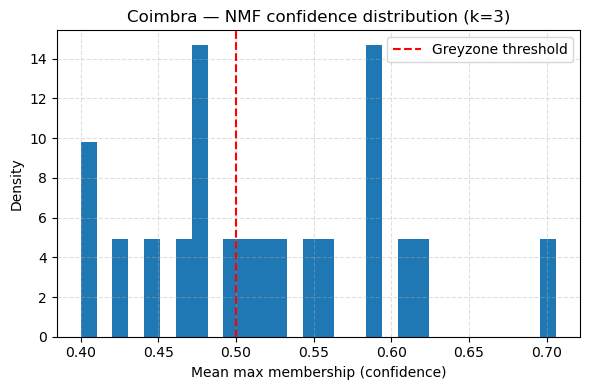

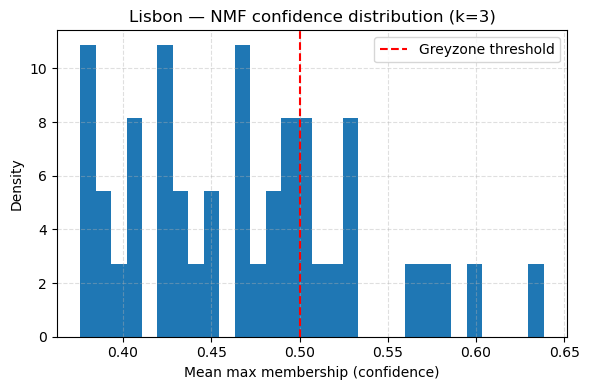

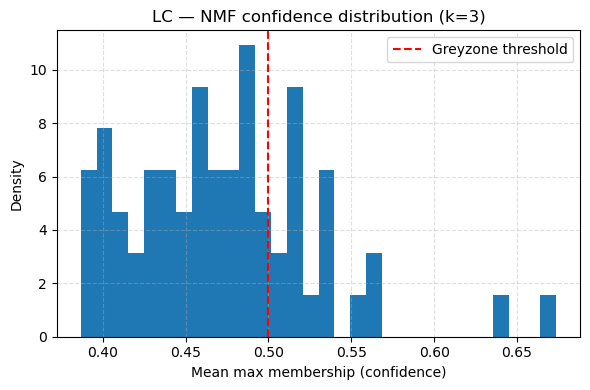

In [66]:
nmf_k3_results = {}

nmf_k3_results["Coimbra"] = nmf_k3_analysis(
    Coimbra_nmf_df,
    "Coimbra",
    patients_coimbra   # greyzone da k=2
)

nmf_k3_results["Lisbon"] = nmf_k3_analysis(
    Lisbon_nmf_df,
    "Lisbon",
    patients_lisbon
)

nmf_k3_results["LC"] = nmf_k3_analysis(
    LC_nmf_df,
    "LC",
    patients_lc
)
# Coimbra
plot_nmf_k3_membership_distribution(
    nmf_k3_results["Coimbra"][1],
    "Coimbra"
)

# Lisbon
plot_nmf_k3_membership_distribution(
    nmf_k3_results["Lisbon"][1],
    "Lisbon"
)

# LC
plot_nmf_k3_membership_distribution(
    nmf_k3_results["LC"][1],
    "LC"
)

In [17]:
print(len(Coimbra_nmf_df))
print(Coimbra_nmf_df.shape)

20
(20, 115)


In [18]:
from sklearn.decomposition import NMF
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment

def nmf_k3_grey_matrix(df, patients_grey, n_runs=50):

    X = df.values if hasattr(df, "values") else df
    k = 3

    W_list = []

    # ─────────────────────────
    # RUN MULTIPLE
    # ─────────────────────────
    for seed in range(n_runs):
        nmf = NMF(n_components=k, init='random', max_iter=10000, random_state=seed)
        W = nmf.fit_transform(X)

        W_norm = W / W.sum(axis=1, keepdims=True)
        W_list.append(W_norm)

    W_list = np.array(W_list)

    # ─────────────────────────
    # ALIGNMENT
    # ─────────────────────────
    ref = W_list[0]
    W_aligned = [ref]

    for W in W_list[1:]:

        cost = np.zeros((k, k))

        for i in range(k):
            for j in range(k):
                cost[i, j] = np.linalg.norm(ref[:, i] - W[:, j])

        _, col_ind = linear_sum_assignment(cost)
        W_aligned.append(W[:, col_ind])

    W_aligned = np.array(W_aligned)

    # ─────────────────────────
    # MEDIA
    # ─────────────────────────
    W_mean = W_aligned.mean(axis=0)

    df_W = pd.DataFrame(
        W_mean,
        index=df.index,
        columns=[f"C{i}" for i in range(k)]
    )

    # ─────────────────────────
    # SOLO GREY
    # ─────────────────────────
    grey_in_df = [p for p in patients_grey if p in df.index]
    df_W = df_W.loc[grey_in_df]

    # ─────────────────────────
    # ORDINA PER AMBIGUITÀ
    # ─────────────────────────
    df_W["max"] = df_W.max(axis=1)
    df_W = df_W.sort_values("max")

    print("\n--- NMF greyzone matrix ---")
    print(df_W.round(3))

    return df_W.drop(columns="max")

In [19]:
nmf_k3_grey_matrix(Coimbra_nmf_df, patients_coimbra)


--- NMF greyzone matrix ---
           C0     C1     C2    max
104804  0.353  0.273  0.374  0.374
102357  0.394  0.364  0.243  0.394
103698  0.299  0.399  0.302  0.399
107702  0.169  0.415  0.416  0.416
100111  0.583  0.142  0.274  0.583


,C0,C1,C2
104804,0.353224,0.273050,0.373726
102357,0.393600,0.363628,0.242772
103698,0.299227,0.398557,0.302217
107702,0.168573,0.415027,0.416400
100111,0.583162,0.142399,0.274439


In [20]:
nmf_k3_grey_matrix(LC_nmf_df, patients_lc)


--- NMF greyzone matrix ---
           C0     C1     C2    max
LIS090  0.299  0.354  0.347  0.354
LIS005  0.293  0.357  0.350  0.357
LIS043  0.339  0.366  0.296  0.366
LIS051  0.278  0.366  0.356  0.366
LIS029  0.297  0.333  0.370  0.370
LIS002  0.278  0.371  0.351  0.371
LIS081  0.285  0.339  0.377  0.377
LIS117  0.258  0.359  0.383  0.383
LIS097  0.241  0.383  0.376  0.383
LIS073  0.281  0.385  0.334  0.385
LIS034  0.264  0.387  0.348  0.387
LIS012  0.298  0.392  0.311  0.392
LIS049  0.303  0.303  0.394  0.394
LIS096  0.215  0.399  0.386  0.399
LIS087  0.248  0.347  0.405  0.405
LIS001  0.276  0.318  0.406  0.406
LIS018  0.283  0.412  0.306  0.412
LIS011  0.274  0.313  0.412  0.412
LIS076  0.220  0.358  0.421  0.421
109522  0.425  0.345  0.230  0.425
LIS094  0.207  0.365  0.427  0.427
LIS084  0.233  0.339  0.428  0.428
LIS047  0.290  0.279  0.430  0.430
LIS085  0.263  0.306  0.431  0.431
LIS102  0.269  0.298  0.433  0.433
109089  0.444  0.321  0.235  0.444
LIS004  0.272  0.281  0.44

,C0,C1,C2
LIS090,0.298964,0.354201,0.346836
LIS005,0.293249,0.356630,0.350122
LIS043,0.338515,0.365516,0.295969
LIS051,0.277744,0.366280,0.355975
LIS029,0.296861,0.333264,0.369876
LIS002,0.278286,0.370619,0.351095
LIS081,0.284535,0.338885,0.376580
LIS117,0.258439,0.358960,0.382602
LIS097,0.240941,0.383320,0.375738
LIS073,0.280839,0.385038,0.334123


In [21]:
nmf_k3_grey_matrix(Lisbon_nmf_df, patients_lisbon)


--- NMF greyzone matrix ---
           C0     C1     C2    max
LIS087  0.328  0.320  0.352  0.352
LIS090  0.357  0.326  0.316  0.357
LIS005  0.362  0.293  0.345  0.362
LIS081  0.311  0.323  0.366  0.366
LIS002  0.367  0.273  0.359  0.367
LIS094  0.310  0.320  0.370  0.370
LIS073  0.306  0.384  0.310  0.384
LIS029  0.332  0.284  0.384  0.384
LIS043  0.333  0.388  0.279  0.388
LIS076  0.254  0.358  0.388  0.388
LIS084  0.337  0.260  0.403  0.403
LIS049  0.292  0.302  0.406  0.406
LIS097  0.410  0.261  0.329  0.410
LIS096  0.421  0.242  0.337  0.421
LIS051  0.281  0.423  0.297  0.423
LIS102  0.321  0.241  0.438  0.438
LIS052  0.261  0.484  0.255  0.484
LIS064  0.306  0.484  0.210  0.484
LIS117  0.520  0.095  0.385  0.520


,C0,C1,C2
LIS087,0.327919,0.320472,0.351609
LIS090,0.357169,0.326336,0.316495
LIS005,0.362488,0.292769,0.344744
LIS081,0.310864,0.323316,0.365820
LIS002,0.367411,0.273095,0.359494
LIS094,0.310138,0.319957,0.369905
LIS073,0.305670,0.383874,0.310456
LIS029,0.332225,0.283633,0.384142
LIS043,0.332987,0.388047,0.278966
LIS076,0.254008,0.357607,0.388384


In [22]:
# prendi solo i grey e calcola la loro matrice di similarità
grey_only = Coimbra_df.loc[patients_coimbra]
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(grey_only)
df_sim = pd.DataFrame(sim_matrix, index=patients_coimbra, columns=patients_coimbra)
print(df_sim.round(2))

        103698  107702  104804  100111  102357
103698    1.00   -0.22   -0.16    0.34   -0.07
107702   -0.22    1.00    0.02   -0.43   -0.12
104804   -0.16    0.02    1.00    0.02    0.21
100111    0.34   -0.43    0.02    1.00   -0.12
102357   -0.07   -0.12    0.21   -0.12    1.00


In [69]:
from sklearn.cluster import SpectralCoclustering
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd


# ─────────────────────────
# LABEL ALIGNMENT
# ─────────────────────────
def align_labels(ref_labels, new_labels, k):

    cm = confusion_matrix(
        ref_labels,
        new_labels,
        labels=list(range(k))
    )

    row_ind, col_ind = linear_sum_assignment(-cm)

    mapping = {
        col_ind[i]: row_ind[i]
        for i in range(len(row_ind))
    }

    return np.array([mapping[l] for l in new_labels])


# ─────────────────────────
# MAIN ANALYSIS
# ─────────────────────────
def coclustering_k3_analysis(
    df,
    name,
    patients_grey,
    n_runs=50
):

    # ─────────────────────────
    # KEEP ONLY NUMERIC DATA
    # ─────────────────────────
    numeric_df = df.select_dtypes(include=[np.number])

    X = numeric_df.values

    print(f"\n{'='*60}")
    print(f"{name} — CoClustering k=3 ({n_runs} runs)")
    print(f"{'='*60}")

    # ─────────────────────────
    # MULTIPLE RUNS
    # ─────────────────────────
    all_row_labels = []

    for seed in range(n_runs):

        model = SpectralCoclustering(
            n_clusters=3,
            random_state=seed
        )

        model.fit(X)

        all_row_labels.append(model.row_labels_)

    all_row_labels = np.array(all_row_labels)

    # ─────────────────────────
    # ALIGNMENT
    # ─────────────────────────
    ref = all_row_labels[0]

    all_row_labels_aligned = [ref]

    for labels in all_row_labels[1:]:

        aligned = align_labels(
            ref,
            labels,
            k=3
        )

        all_row_labels_aligned.append(aligned)

    all_row_labels_aligned = np.array(all_row_labels_aligned)

    # ─────────────────────────
    # STABILITY (ARI)
    # ─────────────────────────
    ari_vals = []

    for i in range(n_runs):

        for j in range(i + 1, n_runs):

            ari_vals.append(
                adjusted_rand_score(
                    all_row_labels[i],
                    all_row_labels[j]
                )
            )

    ari_vals = np.array(ari_vals)

    print("\nStability:")
    print(f"ARI mean = {ari_vals.mean():.4f}")
    print(f"ARI std  = {ari_vals.std():.4f}")

    # ─────────────────────────
    # GREY TRACKING
    # ─────────────────────────
    print(f"\n--- Greyzone tracking ---")

    grey_in_df = [
        p for p in patients_grey
        if p in df.index
    ]

    for p in grey_in_df:

        idx = df.index.get_loc(p)

        clusters = all_row_labels_aligned[:, idx]

        counts = (
            pd.Series(clusters)
            .value_counts(normalize=True)
            * 100
        )

        print(f"\n{p}:")

        for c in range(3):

            print(
                f"  Cluster {c}: "
                f"{counts.get(c, 0):.1f}%"
            )

    # ─────────────────────────
    # GREY DISTRIBUTION
    # (% of ALL grey)
    # ─────────────────────────
    print(f"\n--- Grey distribution (% over clusters) ---")

    grey_distribution = {
        c: [] for c in range(3)
    }

    for labels in all_row_labels_aligned:

        total_grey = len(grey_in_df)

        for c in range(3):

            count = 0

            for p in grey_in_df:

                idx = df.index.get_loc(p)

                if labels[idx] == c:
                    count += 1

            frac = (
                count / total_grey
            ) * 100

            grey_distribution[c].append(frac)

    for c in range(3):

        vals = np.array(grey_distribution[c])

        print(f"\nCluster {c}:")

        print(
            f"  Grey assigned here: "
            f"{vals.mean():.1f}% ± {vals.std():.1f}%"
        )

    # ─────────────────────────
    # GREY COMPOSITION
    # (% grey INSIDE cluster)
    # ─────────────────────────
    print(f"\n--- Grey composition per cluster ---")

    patients = df.index.tolist()

    grey_set = set(grey_in_df)

    is_grey = np.array([
        1 if p in grey_set else 0
        for p in patients
    ])

    grey_fracs = {
        c: [] for c in range(3)
    }

    sizes = {
        c: [] for c in range(3)
    }

    for labels in all_row_labels_aligned:

        for c in range(3):

            mask = labels == c

            if mask.sum() > 0:

                frac = (
                    is_grey[mask].mean()
                    * 100
                )

                grey_fracs[c].append(frac)

                sizes[c].append(mask.sum())

    for c in range(3):

        vals = np.array(grey_fracs[c])

        sz = np.array(sizes[c])

        mean_size = sz.mean()

        print(
            f"\nCluster {c} "
            f"(mean size: {mean_size:.1f} patients):"
        )

        print(
            f"  Grey: "
            f"{vals.mean():.1f}% ± {vals.std():.1f}%"
        )

        print(
            f"  Non-grey: "
            f"{100 - vals.mean():.1f}% ± {vals.std():.1f}%"
        )

    # ─────────────────────────
    # STABLE PATIENTS
    # ─────────────────────────
    print(f"\n--- Stable patients (>70%) ---")

    stable_flags = {}

    for p in df.index:

        idx = df.index.get_loc(p)

        counts = np.zeros(3)

        for labels in all_row_labels_aligned:

            counts[labels[idx]] += 1

        counts = counts / n_runs

        stable_flags[p] = (
            counts.max() >= 0.7
        )

    grey_stable = sum(
        stable_flags[p]
        for p in grey_set
    )

    non_grey = [
        p for p in df.index
        if p not in grey_set
    ]

    non_grey_stable = sum(
        stable_flags[p]
        for p in non_grey
    )

    print(
        f"\nGREY: "
        f"{grey_stable}/{len(grey_set)} "
        f"({grey_stable/len(grey_set)*100:.1f}%)"
    )

    print(
        f"NON-GREY: "
        f"{non_grey_stable}/{len(non_grey)} "
        f"({non_grey_stable/len(non_grey)*100:.1f}%)"
    )

    # ─────────────────────────
    # LC DATASET COMPOSITION
    # ─────────────────────────
    if name == "LC":

        print(f"\n--- LC cluster composition ---")

        def get_origin(p):

            return (
                1 if str(p).startswith("LIS")
                else 0
            )

        origins = np.array([
            get_origin(p)
            for p in df.index
        ])

        comps_all = {
            c: [] for c in range(3)
        }

        for labels in all_row_labels_aligned:

            for c in range(3):

                mask = labels == c

                if mask.sum() > 0:

                    lisbon_frac = (
                        origins[mask].mean()
                        * 100
                    )

                    comps_all[c].append(
                        lisbon_frac
                    )

        for c in range(3):

            vals = np.array(comps_all[c])

            print(f"\nCluster {c}:")

            print(
                f"  Lisbon  = "
                f"{vals.mean():.1f}% ± "
                f"{vals.std():.1f}%"
            )

            print(
                f"  Coimbra = "
                f"{100 - vals.mean():.1f}% ± "
                f"{vals.std():.1f}%"
            )

    return all_row_labels_aligned

In [70]:
coclustering_k3_results = {}

coclustering_k3_results["Coimbra"] = coclustering_k3_analysis(
    Coimbra_df, "Coimbra", patients_coimbra
)

coclustering_k3_results["Lisbon"] = coclustering_k3_analysis(
    Lisbon_df, "Lisbon", patients_lisbon
)

coclustering_k3_results["LC"] = coclustering_k3_analysis(
    LC_df, "LC", patients_lc
)


Coimbra — CoClustering k=3 (50 runs)

Stability:
ARI mean = 1.0000
ARI std  = 0.0000

--- Greyzone tracking ---

103698:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

107702:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

104804:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

100111:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

102357:
  Cluster 0: 0.0%
  Cluster 1: 0.0%
  Cluster 2: 100.0%

--- Grey distribution (% over clusters) ---

Cluster 0:
  Grey assigned here: 40.0% ± 0.0%

Cluster 1:
  Grey assigned here: 40.0% ± 0.0%

Cluster 2:
  Grey assigned here: 20.0% ± 0.0%

--- Grey composition per cluster ---

Cluster 0 (mean size: 5.0 patients):
  Grey: 40.0% ± 0.0%
  Non-grey: 60.0% ± 0.0%

Cluster 1 (mean size: 7.0 patients):
  Grey: 28.6% ± 0.0%
  Non-grey: 71.4% ± 0.0%

Cluster 2 (mean size: 8.0 patients):
  Grey: 12.5% ± 0.0%
  Non-grey: 87.5% ± 0.0%

--- Stable patients (>70%) ---

GREY: 5/5 (100.0%)
NON-GREY: 15/15 (100.0%)

Lisbon —

In [25]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np


def cliffs_delta(x, y):
    return (np.sum(x[:, None] > y) - np.sum(x[:, None] < y)) / (len(x)*len(y))


def differential_analysis_grey(df, grey_patients):

    grey_set = set(grey_patients)
    group = np.array([1 if p in grey_set else 0 for p in df.index])

    results = []

    for protein in df.columns:

        values = df[protein].values

        grey_vals = values[group == 1]
        non_grey_vals = values[group == 0]

        if len(grey_vals) < 3 or len(non_grey_vals) < 3:
            continue

        # test statistico
        stat, pval = mannwhitneyu(grey_vals, non_grey_vals, alternative='two-sided')

        # effect size (semplice e robusto)
        diff = grey_vals.mean() - non_grey_vals.mean()

        # effect size non parametrico
        delta = cliffs_delta(grey_vals, non_grey_vals)

        results.append([protein, diff, delta, pval])

    df_res = pd.DataFrame(results, columns=["protein", "diff", "cliff_delta", "pval"])

    # FDR correction
    df_res["FDR"] = multipletests(df_res["pval"], method="fdr_bh")[1]

    df_res = df_res.sort_values("FDR")

    return df_res

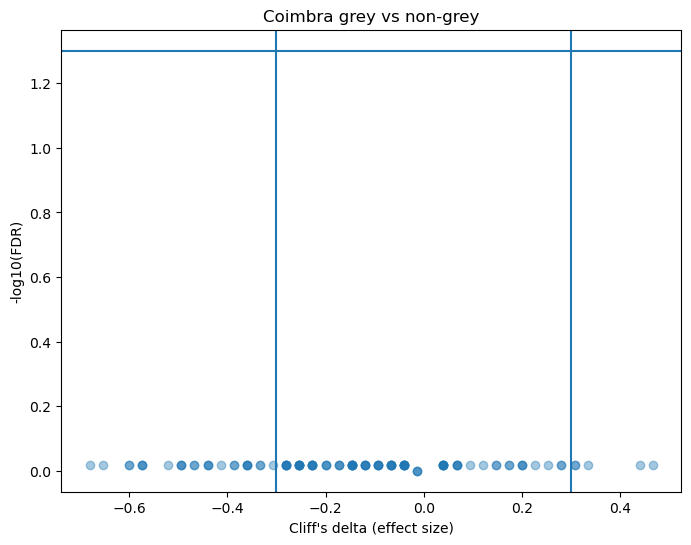

In [26]:
res_Coimbra = differential_analysis_grey(Coimbra_df, patients_coimbra)
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df_res, title="Volcano plot (grey vs non-grey)"):

    df = df_res.copy()

    # evita log di zero
    df["FDR_safe"] = df["FDR"].replace(0, 1e-300)
    df["neglog10FDR"] = -np.log10(df["FDR_safe"])

    # soglie
    sig = (df["FDR"] < 0.05) & (abs(df["cliff_delta"]) > 0.3)

    plt.figure(figsize=(8,6))

    # tutti
    plt.scatter(df["cliff_delta"], df["neglog10FDR"], alpha=0.4)

    # significativi
    plt.scatter(df.loc[sig, "cliff_delta"],
                df.loc[sig, "neglog10FDR"])

    # linee soglia
    plt.axvline(0.3)
    plt.axvline(-0.3)
    plt.axhline(-np.log10(0.05))

    plt.xlabel("Cliff's delta (effect size)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    plt.show()
plot_volcano(res_Coimbra, title="Coimbra grey vs non-grey")

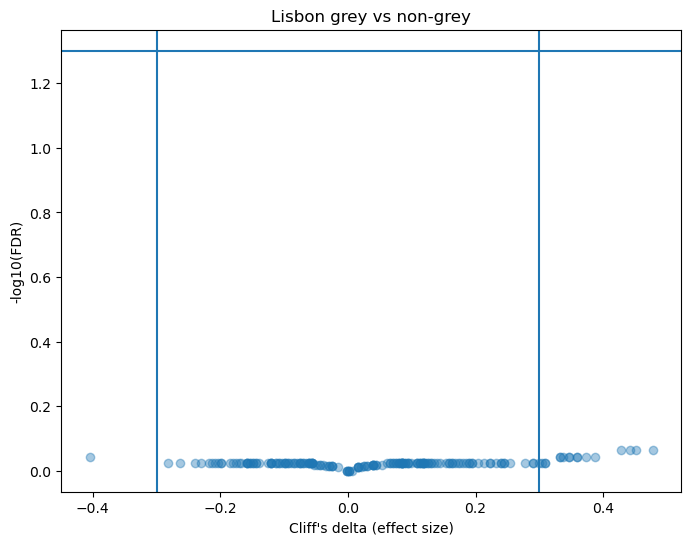

In [27]:
res_Lisbon = differential_analysis_grey(Lisbon_df, patients_lisbon)
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df_res, title="Volcano plot (grey vs non-grey)"):

    df = df_res.copy()

    # evita log di zero
    df["FDR_safe"] = df["FDR"].replace(0, 1e-300)
    df["neglog10FDR"] = -np.log10(df["FDR_safe"])

    # soglie
    sig = (df["FDR"] < 0.05) & (abs(df["cliff_delta"]) > 0.3)

    plt.figure(figsize=(8,6))

    # tutti
    plt.scatter(df["cliff_delta"], df["neglog10FDR"], alpha=0.4)

    # significativi
    plt.scatter(df.loc[sig, "cliff_delta"],
                df.loc[sig, "neglog10FDR"])

    # linee soglia
    plt.axvline(0.3)
    plt.axvline(-0.3)
    plt.axhline(-np.log10(0.05))

    plt.xlabel("Cliff's delta (effect size)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    plt.show()
plot_volcano(res_Lisbon, title="Lisbon grey vs non-grey")

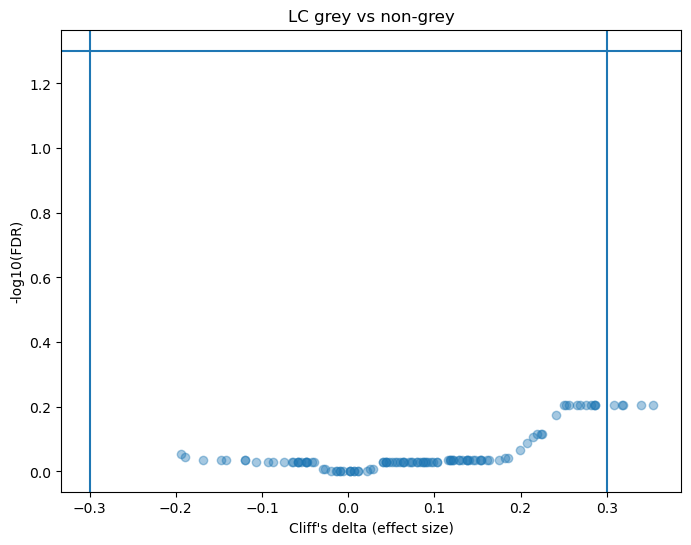

In [28]:
res_LC = differential_analysis_grey(LC_df, patients_lc)
import numpy as np
import matplotlib.pyplot as plt

def plot_volcano(df_res, title="Volcano plot (grey vs non-grey)"):

    df = df_res.copy()

    # evita log di zero
    df["FDR_safe"] = df["FDR"].replace(0, 1e-300)
    df["neglog10FDR"] = -np.log10(df["FDR_safe"])

    # soglie
    sig = (df["FDR"] < 0.05) & (abs(df["cliff_delta"]) > 0.3)

    plt.figure(figsize=(8,6))

    # tutti
    plt.scatter(df["cliff_delta"], df["neglog10FDR"], alpha=0.4)

    # significativi
    plt.scatter(df.loc[sig, "cliff_delta"],
                df.loc[sig, "neglog10FDR"])

    # linee soglia
    plt.axvline(0.3)
    plt.axvline(-0.3)
    plt.axhline(-np.log10(0.05))

    plt.xlabel("Cliff's delta (effect size)")
    plt.ylabel("-log10(FDR)")
    plt.title(title)

    plt.show()
plot_volcano(res_LC, title="LC grey vs non-grey")

In [29]:
char_data = pd.read_excel('Copia di BBA amyloid+ follow-up Lisboa e Coimbra final.xlsx')

In [30]:
char_data

,Code,BBA,idade,sexo,CSF date,CSF data tTau,CSF data pTau,CSF data abeta42,MMSE,comentários,conversão em demência conversão=1,data,tempo follow-up
0,LIS-008,BBA+,63,F,2014-09-02,200,26.00,324.000000,22,NaN,1,2017-10-15 00:00:00,3.120548
1,LIS-011,BBA+,59,F,2015-02-06,540,74.00,504.000000,24,NaN,1,2018-02-15 00:00:00,3.027397
2,LIS-001,BBA+,76,F,2015-01-26,618,95.00,552.000000,27,NaN,1,2021-10-15 00:00:00,6.723288
3,LIS-031,BBA+,67,F,2015-10-09,892,117.00,512.000000,21,NaN,1,2021-11-15 00:00:00,6.106849
4,LIS-029,BBA+,71,M,2015-09-30,702,86.00,558.000000,26,NaN,1,2019-07-15 00:00:00,3.791781
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,107702,Abeta-Positivo,54,F,2018-06-19,564.487205,84.01,415.916096,26,NaN,1,2020,2.000000
67,108726,Abeta-Positivo,55,F,2019-05-20,1206,221.10,480.000000,28,sem follow-up,ND,NaN,NaN
68,109089,Abeta-Positivo,64,M,2019-08-22,1347,204.20,451.000000,25,NaN,1,2021,2.000000
69,109522,Abeta-Positivo,64,M,2019-12-05,105,18.20,417.000000,29,sem follow-up,ND,NaN,NaN


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def normalize_id(x):
    return str(x).replace("-", "")


def followup_analysis(char_data, grey_list, title=""):

    df = char_data.copy()

    # normalizza ID nel dataframe
    df["Code_norm"] = df["Code"].astype(str).apply(normalize_id)

    # normalizza lista grey
    grey_norm = [normalize_id(x) for x in grey_list]

    # definisci gruppi
    df["is_grey"] = df["Code_norm"].isin(grey_norm)

    # rimuovi NaN follow-up
    df = df.dropna(subset=["tempo follow-up"])

    grey = df[df["is_grey"]]["tempo follow-up"]
    non_grey = df[~df["is_grey"]]["tempo follow-up"]

    # ─────────────────────────
    # DEBUG (importantissimo)
    # ─────────────────────────
    print(f"\n=== {title} ===")
    print(f"Matched grey patients: {df['is_grey'].sum()} / {len(grey_norm)}")

    # ─────────────────────────
    # STATISTICHE
    # ─────────────────────────
    print("\nGREY:")
    print(f"  n   = {len(grey)}")
    print(f"  mean = {grey.mean():.2f}")
    print(f"  std  = {grey.std():.2f}")

    print("\nNON-GREY:")
    print(f"  n   = {len(non_grey)}")
    print(f"  mean = {non_grey.mean():.2f}")
    print(f"  std  = {non_grey.std():.2f}")

    # ─────────────────────────
    # PLOT DISTRIBUZIONE GREY
    # ─────────────────────────
    plt.figure()
    plt.hist(grey, alpha=0.7)
    plt.title(f"{title} — Grey follow-up distribution")
    plt.xlabel("Follow-up")
    plt.ylabel("Count")
    plt.show()


=== Coimbra ===
Matched grey patients: 5 / 5

GREY:
  n   = 5
  mean = 2.40
  std  = 1.52

NON-GREY:
  n   = 54
  mean = 3.05
  std  = 1.82


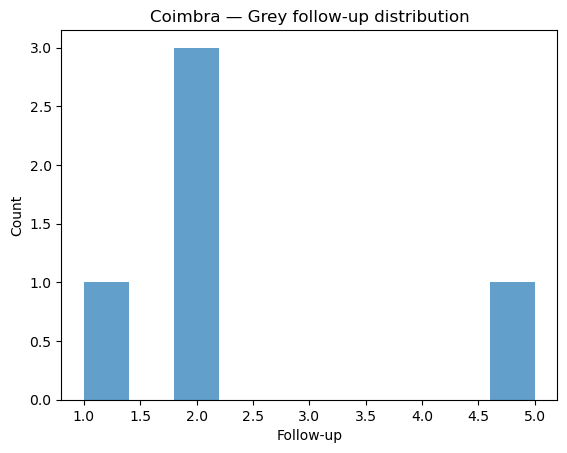


=== Lisbon ===
Matched grey patients: 15 / 19

GREY:
  n   = 15
  mean = 3.29
  std  = 1.55

NON-GREY:
  n   = 44
  mean = 2.90
  std  = 1.87


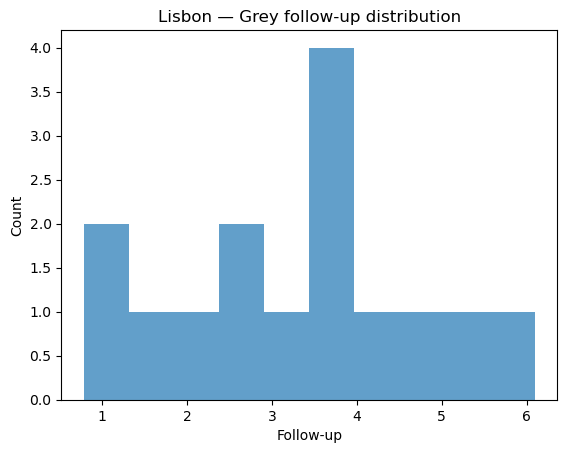


=== LC ===
Matched grey patients: 32 / 38

GREY:
  n   = 32
  mean = 3.33
  std  = 1.84

NON-GREY:
  n   = 27
  mean = 2.60
  std  = 1.68


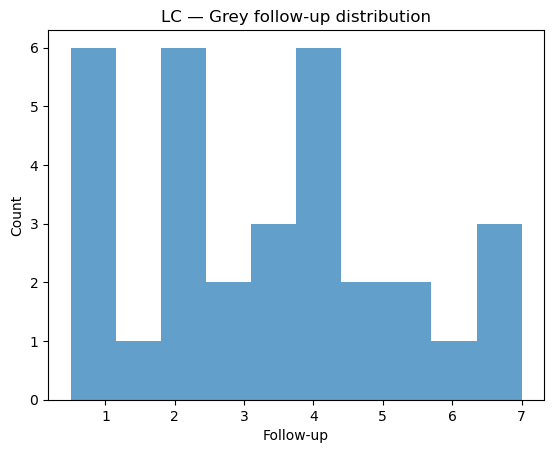

In [32]:
followup_analysis(char_data, patients_coimbra, "Coimbra")
followup_analysis(char_data, patients_lisbon, "Lisbon")
followup_analysis(char_data, patients_lc, "LC")

In [33]:
def cluster_time_to_conversion_summary(all_labels_aligned, df, char_data,
                                       id_col="Code",
                                       time_col="tempo follow-up",
                                       n_clusters=3):
    """
    Calcola media e std del time to conversion per cluster,
    usando le labels già allineate prodotte da kmeans_k3_analysis.

    Nota: normalizza gli ID tipo LIS-008 -> LIS008.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    # copia tabella clinica e normalizza ID
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)

    # converte il tempo in numerico
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa: ID paziente normalizzato -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea i tempi all'ordine dei pazienti nel dataframe usato per il clustering
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per cluster ---")

    cluster_means = {c: [] for c in range(n_clusters)}
    cluster_stds = {c: [] for c in range(n_clusters)}
    cluster_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_labels_aligned:
        labels = np.array(labels)

        for c in range(n_clusters):
            vals = time_to_conversion[labels == c].dropna()

            if len(vals) > 0:
                cluster_means[c].append(vals.mean())
                cluster_stds[c].append(vals.std())
                cluster_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(cluster_means[c])
        stds = np.array(cluster_stds[c])
        sizes = np.array(cluster_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")


In [34]:
labels_lc = kmeans_k3_analysis(LC_df, "LC", patients_lc)

cluster_time_to_conversion_summary(
    all_labels_aligned=labels_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)



LC — KMeans k=3 (50 runs)

--- Label alignment quality ---
Pazienti con stessa etichetta della run 0:
  Media:  90.8%
  Min:    89.6%
  Max:    98.5%
  Std:    2.3%

Stability:
ARI mean = 0.9380
ARI std  = 0.0804

--- Greyzone tracking ---

LIS090:
  Cluster 0: 100.0%

LIS011:
  Cluster 0: 100.0%

LIS001:
  Cluster 0: 100.0%

LIS029:
  Cluster 0: 100.0%

LIS005:
  Cluster 0: 100.0%

LIS012:
  Cluster 2: 100.0%

LIS018:
  Cluster 2: 100.0%

LIS002:
  Cluster 0: 100.0%

LIS043:
  Cluster 2: 100.0%

LIS047:
  Cluster 0: 100.0%

LIS051:
  Cluster 0: 96.0%
  Cluster 2: 4.0%

LIS049:
  Cluster 0: 100.0%

LIS076:
  Cluster 0: 100.0%

LIS004:
  Cluster 0: 100.0%

LIS034:
  Cluster 0: 96.0%
  Cluster 2: 4.0%

LIS058:
  Cluster 0: 100.0%

LIS073:
  Cluster 0: 94.0%
  Cluster 2: 6.0%

LIS081:
  Cluster 0: 100.0%

LIS084:
  Cluster 0: 100.0%

LIS085:
  Cluster 0: 100.0%

LIS087:
  Cluster 0: 100.0%

LIS088:
  Cluster 0: 100.0%

LIS094:
  Cluster 0: 100.0%

LIS096:
  Cluster 0: 100.0%

LIS097:
  C

In [35]:
def ward_time_to_conversion_summary(labels, df, char_data,
                                    id_col="Code",
                                    time_col="tempo follow-up"):
    """
    Calcola media e std del time to conversion per ogni cluster Ward.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    labels = np.array(labels)

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> tempo
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine di df.index
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per Ward cluster ---")

    for c in sorted(np.unique(labels)):
        vals = time_to_conversion[labels == c].dropna()

        print(f"\nCluster {c}:")
        print(f"  N pazienti con dato: {len(vals)}")

        if len(vals) > 0:
            print(f"  Time to conversion mean: {vals.mean():.2f}")
            print(f"  Time to conversion std:  {vals.std():.2f}")
        else:
            print("  Time to conversion mean: NaN")
            print("  Time to conversion std:  NaN")


In [36]:
labels_ward_lc = ward_k3_analysis(LC_df, "LC", patients_lc)

ward_time_to_conversion_summary(
    labels=labels_ward_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up"
)



LC — Ward k=3

--- Grey patients per cluster ---

--- Grey patients distribution ---
Cluster 0: 26.3% (10 patients)
Cluster 1: 28.9% (11 patients)
Cluster 2: 44.7% (17 patients)

--- Grey composition per cluster ---

Cluster 0 (21 patients):
  Grey:     47.6% (10)
  Non-grey: 52.4% (11)

Cluster 1 (25 patients):
  Grey:     44.0% (11)
  Non-grey: 56.0% (14)

Cluster 2 (21 patients):
  Grey:     81.0% (17)
  Non-grey: 19.0% (4)

--- LC cluster composition ---

Cluster 0 (21 patients):
Lisbon: 0.0%
Coimbra: 100.0%

Cluster 1 (25 patients):
Lisbon: 96.0%
Coimbra: 4.0%

Cluster 2 (21 patients):
Lisbon: 100.0%
Coimbra: 0.0%

--- Time to conversion per Ward cluster ---

Cluster 0:
  N pazienti con dato: 19
  Time to conversion mean: 2.26
  Time to conversion std:  1.72

Cluster 1:
  N pazienti con dato: 19
  Time to conversion mean: 2.97
  Time to conversion std:  1.62

Cluster 2:
  N pazienti con dato: 17
  Time to conversion mean: 3.93
  Time to conversion std:  1.80


In [37]:
def spectral_time_to_conversion_summary(all_labels_aligned, df, char_data,
                                        id_col="Code",
                                        time_col="tempo follow-up",
                                        n_clusters=3):
    """
    Calcola media e std del time to conversion per ogni cluster Spectral,
    usando le labels allineate prodotte da spectral_k3_analysis.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine di df.index
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per Spectral cluster ---")

    cluster_means = {c: [] for c in range(n_clusters)}
    cluster_stds = {c: [] for c in range(n_clusters)}
    cluster_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_labels_aligned:
        labels = np.array(labels)

        for c in range(n_clusters):
            vals = time_to_conversion[labels == c].dropna()

            if len(vals) > 0:
                cluster_means[c].append(vals.mean())
                cluster_stds[c].append(vals.std())
                cluster_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(cluster_means[c])
        stds = np.array(cluster_stds[c])
        sizes = np.array(cluster_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")


In [38]:
labels_spectral_lc = spectral_k3_analysis(
    df=LC_df,
    name="LC",
    patients_grey=patients_lc,
    n_runs=50,
    gamma=1.0
)

spectral_time_to_conversion_summary(
    all_labels_aligned=labels_spectral_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)



LC — Spectral k=3 (50 runs)

--- Label alignment quality ---
Media: 99.9%
Min:   97.0%
Max:   100.0%
Std:   0.5%

Stability:
ARI mean = 0.9954
ARI std  = 0.0167

--- Greyzone tracking ---

LIS090:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS011:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS001:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS029:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS005:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS012:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS018:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS002:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS043:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS047:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS051:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS049:
  Cluster 0: 100.0%
  Cluster 1: 0.0%
  Cluster 2: 0.0%

LIS076:
  Cluster 0: 100.0%
  

In [39]:
def optics_time_to_conversion_summary(labels, df, char_data,
                                      id_col="Code",
                                      time_col="tempo follow-up"):
    """
    Calcola media e std del time to conversion per ogni cluster OPTICS,
    includendo anche -1 come NOISE.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    labels = np.array(labels)

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine di df.index
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per OPTICS cluster ---")

    for c in sorted(np.unique(labels)):
        vals = time_to_conversion[labels == c].dropna()
        label = "NOISE" if c == -1 else f"Cluster {c}"

        print(f"\n{label}:")
        print(f"  N pazienti con dato: {len(vals)}")

        if len(vals) > 0:
            print(f"  Time to conversion mean: {vals.mean():.2f}")
            print(f"  Time to conversion std:  {vals.std():.2f}")
        else:
            print("  Time to conversion mean: NaN")
            print("  Time to conversion std:  NaN")


In [40]:
model = OPTICS(min_samples=8, xi=0.03, metric="cosine")
labels_optics_lc = model.fit_predict(LC_df)

optics_k3_analysis(
    df=LC_df,
    labels=labels_optics_lc,
    name="LC",
    grey_patients=patients_lc
)

optics_time_to_conversion_summary(
    labels=labels_optics_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up"
)



LC — Grey distribution (OPTICS)
NOISE: 68.4%
Cluster 0: 18.4%
Cluster 1: 7.9%
Cluster 2: 5.3%

--- Grey composition per cluster ---

NOISE (26 patients):
  Grey:     100.0% (26)
  Non-grey: 0.0% (0)

Cluster 0 (11 patients):
  Grey:     63.6% (7)
  Non-grey: 36.4% (4)

Cluster 1 (14 patients):
  Grey:     21.4% (3)
  Non-grey: 78.6% (11)

Cluster 2 (16 patients):
  Grey:     12.5% (2)
  Non-grey: 87.5% (14)

--- LC cluster composition ---

NOISE (26 patients):
  Lisbon:  69.2%
  Coimbra: 30.8%

Cluster 0 (11 patients):
  Lisbon:  100.0%
  Coimbra: 0.0%

Cluster 1 (14 patients):
  Lisbon:  0.0%
  Coimbra: 100.0%

Cluster 2 (16 patients):
  Lisbon:  100.0%
  Coimbra: 0.0%

--- Time to conversion per OPTICS cluster ---

NOISE:
  N pazienti con dato: 23
  Time to conversion mean: 3.48
  Time to conversion std:  1.73

Cluster 0:
  N pazienti con dato: 8
  Time to conversion mean: 3.76
  Time to conversion std:  2.22

Cluster 1:
  N pazienti con dato: 12
  Time to conversion mean: 1.75
  Ti

In [41]:
def nmf_time_to_conversion_summary(all_labels, W_aligned, df, char_data,
                                   id_col="Code",
                                   time_col="tempo follow-up",
                                   n_clusters=3):
    """
    Riassume il time to conversion per NMF k=3 in due modi:

    1. Hard assignment:
       usa argmax/all_labels, come negli altri clustering.

    2. Soft assignment:
       usa le membership W_aligned come pesi per ogni componente.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine dei pazienti in df
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    # tieni solo pazienti con time disponibile
    valid_mask = time_to_conversion.notna().values
    t = time_to_conversion.values.astype(float)

    all_labels = np.array(all_labels)
    W_aligned = np.array(W_aligned)

    print(f"\n--- NMF time to conversion: hard assignment (argmax) ---")

    hard_means = {c: [] for c in range(n_clusters)}
    hard_stds = {c: [] for c in range(n_clusters)}
    hard_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_labels:
        labels = np.array(labels)

        for c in range(n_clusters):
            mask = (labels == c) & valid_mask
            vals = t[mask]

            if len(vals) > 0:
                hard_means[c].append(vals.mean())
                hard_stds[c].append(vals.std())
                hard_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(hard_means[c])
        stds = np.array(hard_stds[c])
        sizes = np.array(hard_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")

    print(f"\n--- NMF time to conversion: soft weighted membership ---")

    soft_means = {c: [] for c in range(n_clusters)}
    soft_stds = {c: [] for c in range(n_clusters)}
    effective_ns = {c: [] for c in range(n_clusters)}

    for W in W_aligned:
        W = np.array(W)

        for c in range(n_clusters):
            weights = W[:, c]

            weights_valid = weights[valid_mask]
            t_valid = t[valid_mask]

            if weights_valid.sum() > 0:
                weighted_mean = np.average(t_valid, weights=weights_valid)

                weighted_var = np.average(
                    (t_valid - weighted_mean) ** 2,
                    weights=weights_valid
                )

                weighted_std = np.sqrt(weighted_var)

                # effective sample size pesata
                effective_n = (weights_valid.sum() ** 2) / np.sum(weights_valid ** 2)

                soft_means[c].append(weighted_mean)
                soft_stds[c].append(weighted_std)
                effective_ns[c].append(effective_n)

    for c in range(n_clusters):
        means = np.array(soft_means[c])
        stds = np.array(soft_stds[c])
        ens = np.array(effective_ns[c])

        print(f"\nComponent {c}:")
        print(f"  Effective N:              {ens.mean():.1f}")
        print(f"  Weighted time mean:       {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Weighted time std:        {stds.mean():.2f} ± {stds.std():.2f}")


In [42]:
all_labels_nmf_lc, W_aligned_lc = nmf_k3_analysis(
    df=LC_nmf_df,
    name="LC",
    patients_grey_k2=patients_lc,
    n_runs=50
)

nmf_time_to_conversion_summary(
    all_labels=all_labels_nmf_lc,
    W_aligned=W_aligned_lc,
    df=LC_nmf_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)



LC — NMF k=3 (50 runs)

--- Greyzone (k=2) tracking in k=3 ---

LIS090:
  Cluster 0: 12.0%
  Cluster 1: 46.0%
  Cluster 2: 42.0%

LIS011:
  Cluster 0: 6.0%
  Cluster 1: 22.0%
  Cluster 2: 72.0%

LIS001:
  Cluster 0: 6.0%
  Cluster 1: 24.0%
  Cluster 2: 70.0%

LIS029:
  Cluster 0: 14.0%
  Cluster 1: 30.0%
  Cluster 2: 56.0%

LIS005:
  Cluster 0: 10.0%
  Cluster 1: 48.0%
  Cluster 2: 42.0%

LIS012:
  Cluster 0: 14.0%
  Cluster 1: 76.0%
  Cluster 2: 10.0%

LIS018:
  Cluster 0: 6.0%
  Cluster 1: 90.0%
  Cluster 2: 4.0%

LIS002:
  Cluster 0: 8.0%
  Cluster 1: 54.0%
  Cluster 2: 38.0%

LIS043:
  Cluster 0: 34.0%
  Cluster 1: 60.0%
  Cluster 2: 6.0%

LIS047:
  Cluster 0: 12.0%
  Cluster 1: 8.0%
  Cluster 2: 80.0%

LIS051:
  Cluster 0: 8.0%
  Cluster 1: 46.0%
  Cluster 2: 46.0%

LIS049:
  Cluster 0: 16.0%
  Cluster 1: 20.0%
  Cluster 2: 64.0%

LIS076:
  Cluster 0: 0.0%
  Cluster 1: 42.0%
  Cluster 2: 58.0%

LIS004:
  Cluster 0: 8.0%
  Cluster 1: 10.0%
  Cluster 2: 82.0%

LIS034:
  Cluster 0: 

In [43]:
def coclustering_time_to_conversion_summary(all_row_labels_aligned, df, char_data,
                                            id_col="Code",
                                            time_col="tempo follow-up",
                                            n_clusters=3):
    """
    Calcola media e std del time to conversion per ogni row-cluster
    prodotto da SpectralCoclustering.

    Gestisce ID tipo LIS-008 in char_data e LIS008 nel dataframe clustering.
    """

    def normalize_id(x):
        return str(x).replace("-", "").strip()

    all_row_labels_aligned = np.array(all_row_labels_aligned)

    # prepara char_data
    char_tmp = char_data.copy()
    char_tmp["patient_id_norm"] = char_tmp[id_col].apply(normalize_id)
    char_tmp[time_col] = pd.to_numeric(char_tmp[time_col], errors="coerce")

    # mappa ID paziente -> time to conversion
    time_map = char_tmp.set_index("patient_id_norm")[time_col]

    # allinea il tempo all'ordine dei pazienti in df
    patient_ids_norm = [normalize_id(p) for p in df.index]
    time_to_conversion = pd.Series(patient_ids_norm, index=df.index).map(time_map)

    print(f"\n--- Time to conversion per CoClustering row-cluster ---")

    cluster_means = {c: [] for c in range(n_clusters)}
    cluster_stds = {c: [] for c in range(n_clusters)}
    cluster_sizes = {c: [] for c in range(n_clusters)}

    for labels in all_row_labels_aligned:
        labels = np.array(labels)

        for c in range(n_clusters):
            vals = time_to_conversion[labels == c].dropna()

            if len(vals) > 0:
                cluster_means[c].append(vals.mean())
                cluster_stds[c].append(vals.std())
                cluster_sizes[c].append(len(vals))

    for c in range(n_clusters):
        means = np.array(cluster_means[c])
        stds = np.array(cluster_stds[c])
        sizes = np.array(cluster_sizes[c])

        print(f"\nCluster {c}:")
        print(f"  N medio pazienti con dato: {sizes.mean():.1f}")
        print(f"  Time to conversion mean:  {means.mean():.2f} ± {means.std():.2f}")
        print(f"  Time to conversion std:   {stds.mean():.2f} ± {stds.std():.2f}")


In [44]:
labels_coclustering_lc = coclustering_k3_analysis(
    df=LC_df,
    name="LC",
    patients_grey=patients_lc,
    n_runs=50
)

coclustering_time_to_conversion_summary(
    all_row_labels_aligned=labels_coclustering_lc,
    df=LC_df,
    char_data=char_data,
    time_col="tempo follow-up",
    n_clusters=3
)



LC — CoClustering k=3 (50 runs)

Stability:
ARI mean = 0.9251
ARI std  = 0.0839

--- Greyzone tracking ---

LIS090:
  Cluster 0: 0.0%
  Cluster 1: 68.0%
  Cluster 2: 32.0%

LIS011:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS001:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS029:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS005:
  Cluster 0: 0.0%
  Cluster 1: 68.0%
  Cluster 2: 32.0%

LIS012:
  Cluster 0: 0.0%
  Cluster 1: 0.0%
  Cluster 2: 100.0%

LIS018:
  Cluster 0: 0.0%
  Cluster 1: 0.0%
  Cluster 2: 100.0%

LIS002:
  Cluster 0: 0.0%
  Cluster 1: 68.0%
  Cluster 2: 32.0%

LIS043:
  Cluster 0: 0.0%
  Cluster 1: 0.0%
  Cluster 2: 100.0%

LIS047:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS051:
  Cluster 0: 0.0%
  Cluster 1: 68.0%
  Cluster 2: 32.0%

LIS049:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS076:
  Cluster 0: 0.0%
  Cluster 1: 100.0%
  Cluster 2: 0.0%

LIS004:
  Cluster 0: 0.0%
  Cluster 1: 100.0%


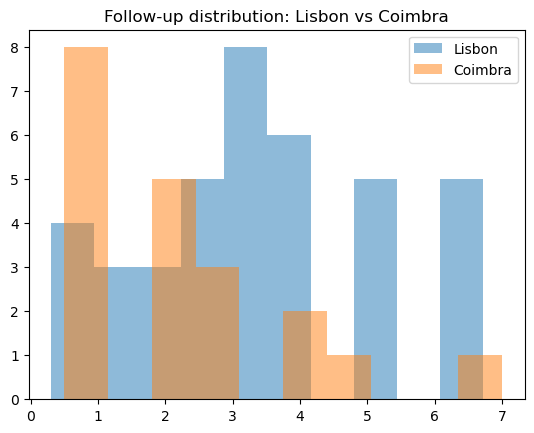

In [45]:
import matplotlib.pyplot as plt

lisbon = char_data[char_data["Code"].str.contains("LIS", na=False)]["tempo follow-up"]
coimbra = char_data[~char_data["Code"].str.contains("LIS", na=False)]["tempo follow-up"]

plt.hist(lisbon, alpha=0.5, label="Lisbon")
plt.hist(coimbra, alpha=0.5, label="Coimbra")
plt.legend()
plt.title("Follow-up distribution: Lisbon vs Coimbra")
plt.show()

In [120]:
char_data

,Code,BBA,idade,sexo,CSF date,CSF data tTau,CSF data pTau,CSF data abeta42,MMSE,comentários,conversão em demência conversão=1,data,tempo follow-up,Code_norm
0,LIS-008,BBA+,63,F,2014-09-02,200,26.00,324.000000,22,NaN,1,2017-10-15 00:00:00,3.120548,LIS008
1,LIS-011,BBA+,59,F,2015-02-06,540,74.00,504.000000,24,NaN,1,2018-02-15 00:00:00,3.027397,LIS011
2,LIS-001,BBA+,76,F,2015-01-26,618,95.00,552.000000,27,NaN,1,2021-10-15 00:00:00,6.723288,LIS001
3,LIS-031,BBA+,67,F,2015-10-09,892,117.00,512.000000,21,NaN,1,2021-11-15 00:00:00,6.106849,LIS031
4,LIS-029,BBA+,71,M,2015-09-30,702,86.00,558.000000,26,NaN,1,2019-07-15 00:00:00,3.791781,LIS029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,107702,Abeta-Positivo,54,F,2018-06-19,564.487205,84.01,415.916096,26,NaN,1,2020,2.000000,107702
67,108726,Abeta-Positivo,55,F,2019-05-20,1206,221.10,480.000000,28,sem follow-up,ND,NaN,NaN,108726
68,109089,Abeta-Positivo,64,M,2019-08-22,1347,204.20,451.000000,25,NaN,1,2021,2.000000,109089
69,109522,Abeta-Positivo,64,M,2019-12-05,105,18.20,417.000000,29,sem follow-up,ND,NaN,NaN,109522


In [108]:
# ─────────────────────────
# 1. normalizza ID (rimuove trattino)
# ─────────────────────────
def normalize_id(x):
    return str(x).replace("-", "")

char_data["Code_norm"] = char_data["Code"].astype(str).apply(normalize_id)
LC_df["Code_norm"] = LC_df.index.map(normalize_id)
LC_subset["origin"] = LC_subset.index.map(
    lambda x: "Lisbon" if "LIS" in x else "Coimbra"
)

# ─────────────────────────
# 2. seleziona pazienti con time ≤ 3
# ─────────────────────────
subset_codes = char_data[
    (char_data["tempo follow-up"] <= 3)
]["Code_norm"].dropna().unique()

# ─────────────────────────
# 3. filtra LC_df
# ─────────────────────────
LC_subset = LC_df[LC_df["Code_norm"].isin(subset_codes)]

print(f"Pazienti selezionati: {LC_subset.shape[0]}")
LC_subset.head()
LC_subset = LC_df[LC_df["Code_norm"].isin(subset_codes)].copy()

Pazienti selezionati: 29


In [109]:
LC_subset["origin"] = LC_subset.index.map(
    lambda x: "Lisbon" if "LIS" in x else "Coimbra"
)

print(LC_subset["origin"].value_counts())

origin
Coimbra    15
Lisbon     14
Name: count, dtype: int64


In [116]:
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd


def align_labels(ref, labels, k):
    cm = confusion_matrix(ref, labels, labels=list(range(k)))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.array([mapping[l] for l in labels])


def kmeans_origin_stability_aligned(df, n_runs=50, k=2):

    X_df = df.drop(columns=["Code_norm", "origin","cluster"], errors="ignore")

    print(X_df.columns)
    
    X = X_df.values
    origins = df["origin"].values

    all_labels = []

    # ─────────────────────────
    # RUN
    # ─────────────────────────
    for seed in range(n_runs):
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        all_labels.append(labels)

    # ─────────────────────────
    # ALIGNMENT
    # ─────────────────────────
    ref = all_labels[0]
    aligned_labels = [ref]

    for labels in all_labels[1:]:
        aligned = align_labels(ref, labels, k)
        aligned_labels.append(aligned)

    # ─────────────────────────
    # COMPOSITION
    # ─────────────────────────
    results = {c: {"Lisbon": [], "Coimbra": []} for c in range(k)}

    for labels in aligned_labels:
        for c in range(k):
            mask = labels == c

            if mask.sum() == 0:
                continue

            lis = np.mean(origins[mask] == "Lisbon") * 100
            coi = np.mean(origins[mask] == "Coimbra") * 100

            results[c]["Lisbon"].append(lis)
            results[c]["Coimbra"].append(coi)

    # ─────────────────────────
    # OUTPUT
    # ─────────────────────────
    print("\n--- Cluster composition (aligned) ---")

    for c in range(k):
        lis = np.array(results[c]["Lisbon"])
        coi = np.array(results[c]["Coimbra"])

        print(f"\nCluster {c}:")
        print(f"  Lisbon  = {lis.mean():.1f}% ± {lis.std():.1f}%")
        print(f"  Coimbra = {coi.mean():.1f}% ± {coi.std():.1f}%")

In [117]:
kmeans_origin_stability_aligned(LC_subset, n_runs=50, k=2)

Index(['A0A0A0MS15', 'A0A0B4J1X8', 'O00533', 'O14594', 'O43505', 'O75326',
       'P00450', 'P00736', 'P01011', 'P01019',
       ...
       'Q99574', 'Q9NQ79', 'Q9NRN5', 'Q9NT99', 'Q9P121', 'Q9UBP4', 'Q9UBX5',
       'Q9ULB1', 'Q9Y4C0', 'Q9Y646'],
      dtype='object', name='Protein.Group', length=114)

--- Cluster composition (aligned) ---

Cluster 0:
  Lisbon  = 0.0% ± 0.0%
  Coimbra = 100.0% ± 0.0%

Cluster 1:
  Lisbon  = 88.2% ± 3.0%
  Coimbra = 11.8% ± 3.0%


In [112]:
LC_subset

Protein.Group,A0A0A0MS15,A0A0B4J1X8,O00533,O14594,O43505,O75326,P00450,P00736,P01011,P01019,...,Q9NRN5,Q9NT99,Q9P121,Q9UBP4,Q9UBX5,Q9ULB1,Q9Y4C0,Q9Y646,Code_norm,origin
LIS035,0.735978,0.147716,0.359418,0.503594,0.213920,0.502979,-0.020229,-0.092002,-0.758650,-0.149226,...,-0.286821,1.940143,1.404062,0.150727,0.562309,1.477404,2.138847,-0.405653,LIS035,Lisbon
LIS024,1.355893,1.990681,-0.910209,-0.580969,-1.920156,-0.056312,0.926122,0.813120,1.536026,-0.090302,...,0.725328,0.662147,-0.220841,-0.646834,-0.532557,-0.294807,-0.065501,-1.388378,LIS024,Lisbon
LIS040,-0.103244,0.793356,-0.315137,-1.234430,0.198359,-0.774952,0.559345,0.428679,0.476288,0.603792,...,0.497797,-0.157027,-1.111090,-0.385459,1.424907,-1.357416,-0.879955,-0.640872,LIS040,Lisbon
LIS051,0.612366,0.552118,-0.739265,-0.940917,0.078240,0.916638,-0.788477,-0.119085,-0.245734,1.116804,...,1.016810,0.784023,-0.709501,-0.237817,-0.016172,0.065009,-0.023357,0.328689,LIS051,Lisbon
LIS057,0.819160,0.476224,-1.961714,-0.734170,-1.172095,0.673681,1.105041,1.283176,1.060301,0.620846,...,1.751353,-0.100494,0.044498,-1.268811,0.453976,-0.391787,-0.432272,0.445060,LIS057,Lisbon
LIS068,0.565078,0.649231,-1.135212,-0.811093,-1.059199,0.857096,-0.203897,0.967579,-0.030590,0.407412,...,1.068029,-0.334541,-0.044749,-1.176163,0.899675,-0.755477,-0.331874,-0.180599,LIS068,Lisbon
LIS076,0.060680,1.302943,-0.558110,0.588329,0.791732,1.420271,-0.371048,0.946622,-0.530340,0.094174,...,0.291912,1.193801,0.068486,-0.500587,0.929853,0.121377,0.370773,-0.095492,LIS076,Lisbon
LIS004,-0.017871,0.322609,-0.289069,0.086110,2.129873,2.569512,-0.519689,0.036410,0.138059,2.987257,...,0.353927,1.709671,1.658996,0.126311,0.291180,1.396708,0.542758,1.411895,LIS004,Lisbon
LIS061,0.946931,0.658951,-1.250060,-0.272251,-0.580320,1.257054,0.138219,1.547614,0.995793,2.738638,...,0.397978,0.319990,-0.811303,-0.954542,1.521189,-0.559639,-1.274079,0.644770,LIS061,Lisbon
LIS073,-0.167866,-0.209541,-0.426633,-0.541922,0.558372,0.067784,-0.224218,0.467796,-0.177336,0.659369,...,0.566535,-0.451210,0.205496,-0.642346,0.225229,0.070007,-0.184427,-0.055990,LIS073,Lisbon


In [113]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd

# dati
X = LC_subset.drop(columns=["Code_norm", "origin","cluster"], errors="ignore").values

# clustering Ward
ward = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels = ward.fit_predict(X)

LC_subset["cluster"] = labels

# composizione
print("\n--- Ward cluster composition ---")
print(pd.crosstab(LC_subset["cluster"], LC_subset["origin"], normalize="index") * 100)


--- Ward cluster composition ---
origin   Coimbra  Lisbon
cluster                 
0          100.0     0.0
1            0.0   100.0


In [52]:
def spectral_origin_stability_cosine(df, n_runs=50, k=2):
    X = df.drop(columns=["Code_norm", "origin", "cluster"], errors="ignore").values
    origins = df["origin"].values

    # ── controlla righe zero ──
    zero_rows = np.where(np.all(X == 0, axis=1))[0]
    if len(zero_rows) > 0:
        print(f"⚠️ Righe zero trovate (verranno rimosse): {df.index[zero_rows].tolist()}")
        mask_valid = np.all(X != 0, axis=1)
        X = X[mask_valid]
        origins = origins[mask_valid]

    # ── cosine affinity matrix ──
    W = cosine_similarity(X)

    # ── clip valori fuori range e sostituisci NaN ──
    W = np.nan_to_num(W, nan=0.0)
    W = np.clip(W, 0, 1)  # cosine può dare valori leggermente negativi per floating point

    results = {c: {"Lisbon": [], "Coimbra": []} for c in range(k)}

    for seed in range(n_runs):
        model = SpectralClustering(
            n_clusters=k,
            affinity="precomputed",
            random_state=seed
        )
        labels = model.fit_predict(W)

        for c in range(k):
            mask = labels == c
            if mask.sum() == 0:
                continue
            lis_frac = np.mean(origins[mask] == "Lisbon") * 100
            coi_frac = np.mean(origins[mask] == "Coimbra") * 100
            results[c]["Lisbon"].append(lis_frac)
            results[c]["Coimbra"].append(coi_frac)

    print("\n--- Spectral (cosine) cluster composition ---")
    for c in range(k):
        lis = np.array(results[c]["Lisbon"])
        coi = np.array(results[c]["Coimbra"])
        print(f"\nCluster {c}:")
        print(f"  Lisbon  = {lis.mean():.1f}% ± {lis.std():.1f}%")
        print(f"  Coimbra = {coi.mean():.1f}% ± {coi.std():.1f}%")

In [53]:
spectral_origin_stability_cosine(LC_subset, n_runs=50, k=2)


--- Spectral (cosine) cluster composition ---

Cluster 0:
  Lisbon  = 42.4% ± 45.1%
  Coimbra = 57.6% ± 45.1%

Cluster 1:
  Lisbon  = 64.7% ± 45.1%
  Coimbra = 35.3% ± 45.1%


In [54]:
from sklearn.cluster import OPTICS
import matplotlib.pyplot as plt
import numpy as np

def optics_reachability_clean(df, min_samples=8, xi=0.03):

    X = df.drop(columns=["Code_norm", "origin", "cluster"], errors="ignore").values

    model = OPTICS(
        min_samples=min_samples,
        xi=xi,
        metric="cosine"
    )
    model.fit(X)

    ordering = model.ordering_
    reachability = model.reachability_[ordering]
    labels = model.labels_[ordering]

    plt.figure(figsize=(10,5))

    unique_labels = np.unique(labels)

    for lab in unique_labels:

        mask = labels == lab

        if lab == -1:
            # 🔴 noise
            plt.scatter(
                np.where(mask)[0],
                reachability[mask],
                s=20,
                label="Noise"
            )
        else:
            # cluster
            plt.scatter(
                np.where(mask)[0],
                reachability[mask],
                s=20,
                label=f"Cluster {lab}"
            )

    plt.plot(reachability, alpha=0.3)  # linea base per continuità

    plt.title(f"OPTICS Reachability (min_samples={min_samples}, xi={xi})")
    plt.xlabel("Points (OPTICS ordering)")
    plt.ylabel("Reachability distance")

    plt.legend()
    plt.show()

    return model

ValueError: could not convert string to float: 'LIS035'

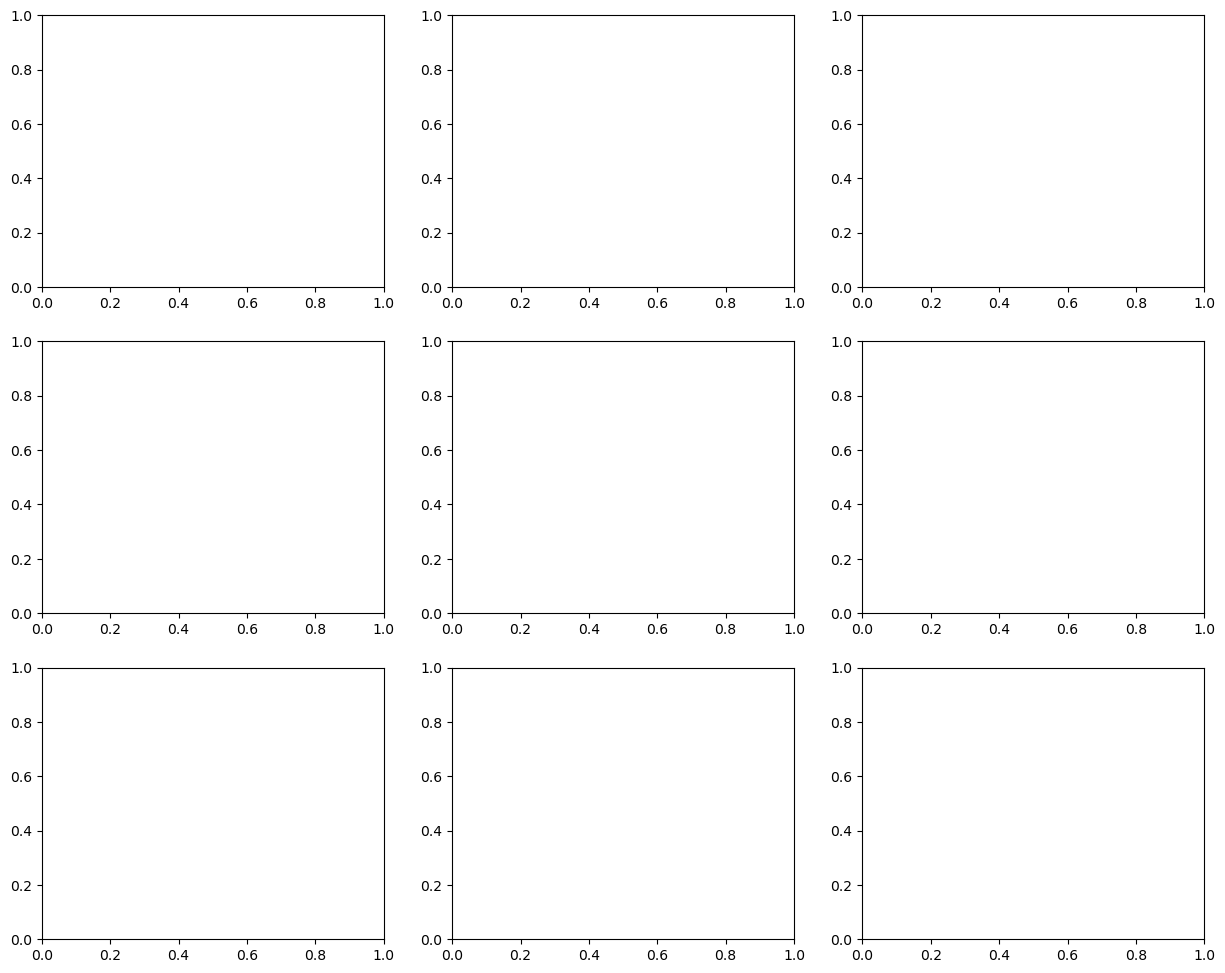

In [55]:
optics_reachability_grid(LC_subset)

In [ ]:
from sklearn.cluster import OPTICS
import pandas as pd
import numpy as np

def optics_origin_composition(df, min_samples=4, xi=0.1):

    X = df.drop(columns=["Code_norm", "origin", "cluster"], errors="ignore").values
    origins = df["origin"].values

    model = OPTICS(
        min_samples=min_samples,
        xi=xi,
        metric="cosine"
    )

    labels = model.fit_predict(X)

    df_res = df.copy()
    df_res["cluster"] = labels

    print("\n--- OPTICS cluster composition ---")

    for c in sorted(np.unique(labels)):

        if c == -1:
            name = "NOISE"
        else:
            name = f"Cluster {c}"

        mask = labels == c

        n = mask.sum()
        lis = np.sum(origins[mask] == "Lisbon")
        coi = np.sum(origins[mask] == "Coimbra")

        print(f"\n{name} ({n} pazienti):")
        
        print(f"  Lisbon:  {lis} ({lis/n*100:.1f}%)")
        print(f"  Coimbra: {coi} ({coi/n*100:.1f}%)")

    return df_res

In [ ]:
optics_res = optics_origin_composition(LC_subset, min_samples=4, xi=0.1)

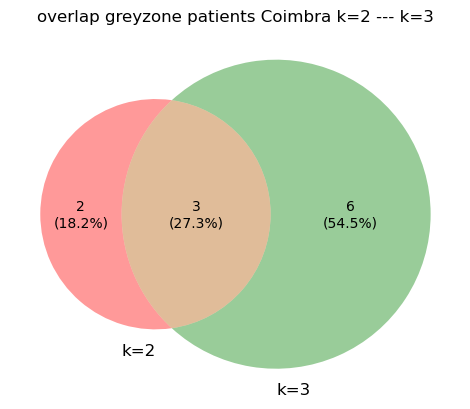

In [104]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

set_a = set(patients_coimbra)
set_b = set(patients_coimbra_k3)

v = venn2([set_a, set_b], set_labels=('k=2', 'k=3'))

only_a = len(set_a - set_b)
only_b = len(set_b - set_a)
both   = len(set_a & set_b)
total  = len(set_a | set_b)

v.get_label_by_id('10').set_text(f'{only_a}\n({only_a/total*100:.1f}%)')
v.get_label_by_id('01').set_text(f'{only_b}\n({only_b/total*100:.1f}%)')
v.get_label_by_id('11').set_text(f'{both}\n({both/total*100:.1f}%)')
plt.title('overlap greyzone patients Coimbra k=2 --- k=3')
plt.savefig('overlap_grey_Coimbra')
plt.show()

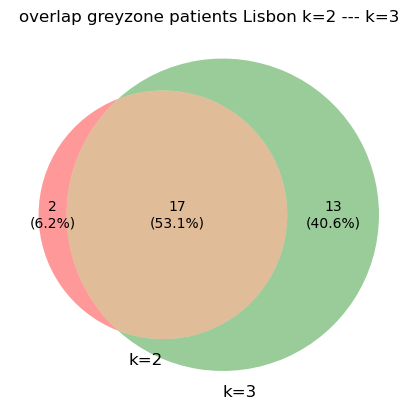

In [105]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

set_a = set(patients_lisbon)
set_b = set(patients_lisbon_k3)

v = venn2([set_a, set_b], set_labels=('k=2', 'k=3'))

only_a = len(set_a - set_b)
only_b = len(set_b - set_a)
both   = len(set_a & set_b)
total  = len(set_a | set_b)

v.get_label_by_id('10').set_text(f'{only_a}\n({only_a/total*100:.1f}%)')
v.get_label_by_id('01').set_text(f'{only_b}\n({only_b/total*100:.1f}%)')
v.get_label_by_id('11').set_text(f'{both}\n({both/total*100:.1f}%)')
plt.title('overlap greyzone patients Lisbon k=2 --- k=3')
plt.savefig('overlap_grey_Lisbon')
plt.show()

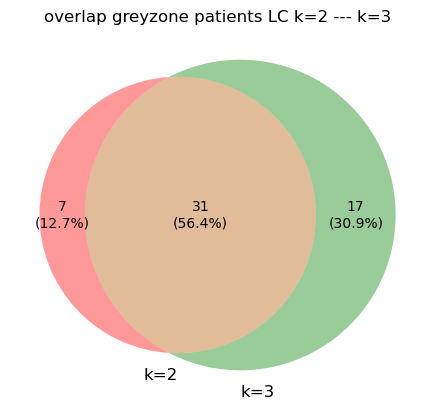

In [106]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

set_a = set(patients_lc)
set_b = set(patients_lc_k3)

v = venn2([set_a, set_b], set_labels=('k=2', 'k=3'))

only_a = len(set_a - set_b)
only_b = len(set_b - set_a)
both   = len(set_a & set_b)
total  = len(set_a | set_b)

v.get_label_by_id('10').set_text(f'{only_a}\n({only_a/total*100:.1f}%)')
v.get_label_by_id('01').set_text(f'{only_b}\n({only_b/total*100:.1f}%)')
v.get_label_by_id('11').set_text(f'{both}\n({both/total*100:.1f}%)')
plt.title('overlap greyzone patients LC k=2 --- k=3')
plt.savefig('overlap_grey_LC')
plt.show()